# Part 2 — EDA & Business Analysis

## Insight 3: Returns are driven more by product-fit / quality issues than delivery delay

**Business question.** Product returns create direct refund loss and hidden operational cost. We test a logistics hypothesis: *do late deliveries increase return rate and refund loss?* If not, the better business lever is to identify which product-related return reasons dominate refund cost.

**Storyline.**

1. Quantify the return/refund problem.
2. Decompose refund loss by return reason.
3. Test whether delivery delay is the main driver.
4. Check whether monthly late-share is a leading indicator of future return rate.
5. Drill down into the largest controllable reason: `wrong_size`.
6. Separate sales-volume effects from true size-fit risk using exposure-adjusted metrics.
7. Identify specific category-size groups to prioritize.
8. Estimate refund savings under simple intervention scenarios.

**Final message.** In this dataset, returns appear to be primarily a product-fit, quality, and expectation-management problem rather than a delivery-delay problem. The highest-impact lever is to reduce `wrong_size`, followed by `defective` and `not_as_described`.


In [1]:
# =========================================
# 0) SETUP
# =========================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

# Try common locations. Keep this list limited to provided competition files only.
CANDIDATE_DIRS = [
    Path("datathon2026") / "data" / "raw",
    Path("data") / "raw",
    Path("/kaggle/input/datathon-2026-round-1"),
    Path("/kaggle/input/datathon2026"),
    Path("."),
]

FILES = {
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "products": "products.csv",
    "returns": "returns.csv",
    "shipments": "shipments.csv",
    "reviews": "reviews.csv",
    "geography": "geography.csv",
}

DATA_RAW = None
for d in CANDIDATE_DIRS:
    if all((d / f).exists() for f in FILES.values()):
        DATA_RAW = d
        break

if DATA_RAW is None:
    raise FileNotFoundError(
        "Cannot find all required CSVs. Put the raw files in one of these folders: "
        + ", ".join(str(d) for d in CANDIDATE_DIRS)
    )

print(f"Using data folder: {DATA_RAW}")

# Load data
orders = pd.read_csv(DATA_RAW / FILES["orders"], low_memory=False)
order_items = pd.read_csv(DATA_RAW / FILES["order_items"], low_memory=False)
products = pd.read_csv(DATA_RAW / FILES["products"], low_memory=False)
returns = pd.read_csv(DATA_RAW / FILES["returns"], low_memory=False)
shipments = pd.read_csv(DATA_RAW / FILES["shipments"], low_memory=False)
reviews = pd.read_csv(DATA_RAW / FILES["reviews"], low_memory=False)
geography = pd.read_csv(DATA_RAW / FILES["geography"], low_memory=False)

print("Loaded files:")
for name, df in {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "returns": returns,
    "shipments": shipments,
    "reviews": reviews,
    "geography": geography,
}.items():
    print(f"- {name:<12}: {df.shape}")


Using data folder: datathon2026\data\raw
Loaded files:
- orders      : (646945, 8)
- order_items : (714669, 7)
- products    : (2412, 8)
- returns     : (39939, 7)
- shipments   : (566067, 4)
- reviews     : (113551, 7)
- geography   : (39948, 4)


## 1) Build analysis tables

We build two levels of data:

- **Order-level table (`order_df`)**: one row per order, used to compare return rate and delivery experience.
- **Return-level table (`returns_prod`)**: one row per return record joined with product attributes, used to analyze return reasons such as `wrong_size`.

Important financial definitions:

- `gross_sales = quantity × unit_price`
- `net_sales = gross_sales − discount_amount`
- `refund_to_gross = refund_total / gross_sales`
- `refund_to_net = refund_total / net_sales`

`net_sales` is included because refund impact should ideally be interpreted after discounts.


In [2]:
# =========================================
# 1) DATA PREP — order-level and return-level tables
# =========================================

# Parse dates
for df, cols in [
    (orders, ["order_date"]),
    (returns, ["return_date"]),
    (shipments, ["ship_date", "delivery_date"]),
    (reviews, ["review_date"]),
]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

# Basic cleaning
orders = orders.dropna(subset=["order_id", "order_date"]).copy()
order_items = order_items.dropna(subset=["order_id", "product_id"]).copy()

# Numeric conversions
for col in ["quantity", "unit_price", "discount_amount"]:
    if col in order_items.columns:
        order_items[col] = pd.to_numeric(order_items[col], errors="coerce")

for col in ["price", "cogs"]:
    if col in products.columns:
        products[col] = pd.to_numeric(products[col], errors="coerce")

for col in ["refund_amount", "return_quantity"]:
    if col in returns.columns:
        returns[col] = pd.to_numeric(returns[col], errors="coerce")

if "shipping_fee" in shipments.columns:
    shipments["shipping_fee"] = pd.to_numeric(shipments["shipping_fee"], errors="coerce")

if "rating" in reviews.columns:
    reviews["rating"] = pd.to_numeric(reviews["rating"], errors="coerce")

# Order item financials
order_items_clean = order_items.dropna(subset=["quantity", "unit_price"]).copy()
order_items_clean["discount_amount"] = order_items_clean["discount_amount"].fillna(0)
order_items_clean["gross_sales"] = order_items_clean["quantity"] * order_items_clean["unit_price"]
order_items_clean["net_sales"] = order_items_clean["gross_sales"] - order_items_clean["discount_amount"]
order_items_clean["net_sales"] = order_items_clean["net_sales"].clip(lower=0)

order_value = (
    order_items_clean.groupby("order_id")
    .agg(
        gross_sales=("gross_sales", "sum"),
        net_sales=("net_sales", "sum"),
        n_lines=("product_id", "size"),
        n_products=("product_id", "nunique"),
        qty_total=("quantity", "sum"),
    )
    .reset_index()
)

# Product mix: dominant category / segment / size by gross_sales per order
prod_cols = ["product_id", "category", "segment", "size"]
oi_prod = order_items_clean.merge(products[prod_cols], on="product_id", how="left")

def top_attr_by_sales(attr):
    tmp = (
        oi_prod.groupby(["order_id", attr], dropna=False)["gross_sales"]
        .sum()
        .reset_index()
        .sort_values(["order_id", "gross_sales"], ascending=[True, False])
    )
    return (
        tmp.drop_duplicates("order_id")[["order_id", attr]]
        .rename(columns={attr: f"top_{attr}"})
    )

top_category = top_attr_by_sales("category")
top_segment = top_attr_by_sales("segment")
top_size = top_attr_by_sales("size")

# Returns at order-level
returns_order = (
    returns.groupby("order_id")
    .agg(
        return_records=("return_id", "size"),
        refund_total=("refund_amount", "sum"),
        n_return_products=("product_id", "nunique"),
        return_quantity=("return_quantity", "sum"),
    )
    .reset_index()
)
returns_order["return_flag"] = returns_order["return_records"] > 0

# Dominant return reason per order
reason_mode = (
    returns.dropna(subset=["order_id", "return_reason"])
    .groupby(["order_id", "return_reason"])
    .size()
    .reset_index(name="cnt")
    .sort_values(["order_id", "cnt"], ascending=[True, False])
    .drop_duplicates("order_id")[["order_id", "return_reason"]]
    .rename(columns={"return_reason": "top_return_reason"})
)

# Shipping metrics
ship = shipments.copy()
ship["ship_to_delivery_days"] = (ship["delivery_date"] - ship["ship_date"]).dt.days

# Review metrics
reviews_order = (
    reviews.dropna(subset=["order_id", "rating"])
    .groupby("order_id")
    .agg(mean_rating=("rating", "mean"), n_reviews=("review_id", "size"))
    .reset_index()
)

# Geography
ord_geo = orders[
    ["order_id", "zip", "order_date", "order_status", "order_source", "device_type", "payment_method"]
].merge(geography[["zip", "region", "city"]], on="zip", how="left")

# Final order-level table
order_df = (
    ord_geo.merge(order_value, on="order_id", how="left")
    .merge(top_category, on="order_id", how="left")
    .merge(top_segment, on="order_id", how="left")
    .merge(top_size, on="order_id", how="left")
    .merge(ship[["order_id", "ship_date", "delivery_date", "ship_to_delivery_days", "shipping_fee"]], on="order_id", how="left")
    .merge(returns_order, on="order_id", how="left")
    .merge(reason_mode, on="order_id", how="left")
    .merge(reviews_order, on="order_id", how="left")
)

# Fill post-merge missing values
order_df["return_flag"] = order_df["return_flag"].fillna(False)
for col in ["refund_total", "return_records", "n_return_products", "return_quantity"]:
    order_df[col] = order_df[col].fillna(0)
for col in ["gross_sales", "net_sales", "n_lines", "n_products", "qty_total"]:
    order_df[col] = order_df[col].fillna(0)

order_df["order_to_delivery_days"] = (order_df["delivery_date"] - order_df["order_date"]).dt.days

# Return-level table with product attributes
returns_prod = returns.merge(
    products[["product_id", "product_name", "category", "segment", "size", "price", "cogs"]],
    on="product_id",
    how="left"
)

print("order_df shape:", order_df.shape)
display(order_df.head(3))
print("returns_prod shape:", returns_prod.shape)
display(returns_prod.head(3))


order_df shape: (646945, 30)


,order_id,zip,order_date,order_status,order_source,device_type,payment_method,region,city,gross_sales,...,shipping_fee,return_records,refund_total,n_return_products,return_quantity,return_flag,top_return_reason,mean_rating,n_reviews,order_to_delivery_days
0,1,1109,2012-07-04,delivered,paid_search,desktop,credit_card,East,Hanoi,7967.54,...,1.37,0.0,0.00,0.0,0.0,False,NaN,5.0,1.0,7.0
1,2,1330,2012-07-04,returned,paid_search,mobile,cod,East,Phu Ly,71163.75,...,2.60,1.0,52458.01,1.0,6.0,True,late_delivery,NaN,NaN,6.0
2,3,1473,2012-07-04,delivered,direct,desktop,credit_card,East,Lao Cai,33660.99,...,2.38,0.0,0.00,0.0,0.0,False,NaN,5.0,1.0,3.0


returns_prod shape: (39939, 13)


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,product_name,category,segment,size,price,cogs
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01,SaigonFlex UC-74,Streetwear,Everyday,M,10426.571034,8987.704231
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37,SaigonCore YY-57,GenZ,Trendy,L,2656.232069,1842.628186
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95,VietMotion UC-07,Streetwear,Everyday,XL,5399.825901,3136.758866


## 2) Descriptive — How large is the return/refund problem?

We track two metrics by order month:

- **Return rate**: share of orders with at least one return record.
- **Refund intensity**: refund as a share of gross/net sales.

This establishes the business size of the problem before diagnosing causes.


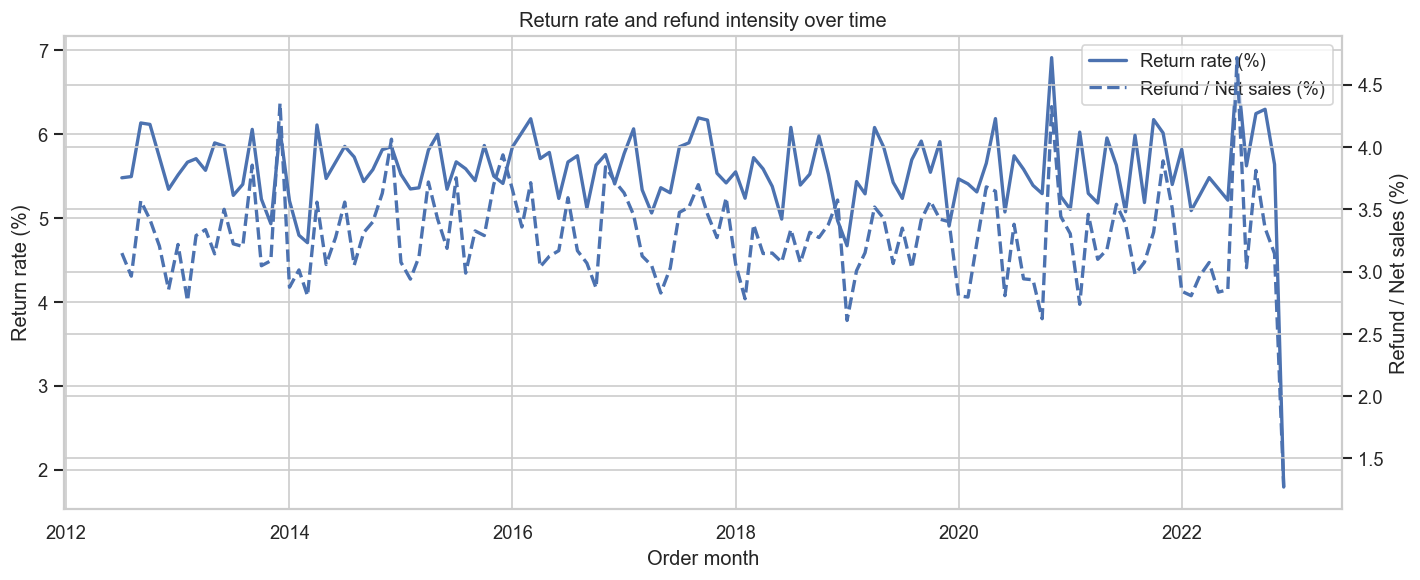

Overall return/refund metrics
- n_orders: 646,945
- return_rate: 5.57%
- refund_total: 510,598,507
- gross_sales: 16,430,476,586
- net_sales: 15,680,869,265
- refund_to_gross: 3.11%
- refund_to_net: 3.26%

Peak months by return rate:


,month,n_orders,return_rate,refund_total,gross_sales,net_sales,refund_to_gross,refund_to_net
100,2020-11-01,1563,0.069098,1842135.19,4.574088e+07,4.260733e+07,0.040273,0.043235
120,2022-07-01,3122,0.067905,4143248.45,9.814178e+07,8.784272e+07,0.042217,0.047167
123,2022-10-01,2097,0.062947,2515900.02,7.519445e+07,7.513702e+07,0.033459,0.033484
122,2022-09-01,2643,0.062429,2966236.91,8.576429e+07,7.781686e+07,0.034586,0.038118
62,2017-09-01,5410,0.061922,4526487.30,1.349440e+08,1.224222e+08,0.033543,0.036974


In [3]:
# =========================================
# 2) DESCRIPTIVE — Return rate and refund intensity over time
# =========================================

base = order_df.dropna(subset=["order_date"]).copy()
base["month"] = base["order_date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    base.groupby("month")
    .agg(
        n_orders=("order_id", "nunique"),
        return_rate=("return_flag", "mean"),
        refund_total=("refund_total", "sum"),
        gross_sales=("gross_sales", "sum"),
        net_sales=("net_sales", "sum"),
    )
    .reset_index()
)

monthly["refund_to_gross"] = np.where(
    monthly["gross_sales"] > 0,
    monthly["refund_total"] / monthly["gross_sales"],
    np.nan
)
monthly["refund_to_net"] = np.where(
    monthly["net_sales"] > 0,
    monthly["refund_total"] / monthly["net_sales"],
    np.nan
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(monthly["month"], monthly["return_rate"] * 100, linewidth=2, label="Return rate (%)")
ax2.plot(monthly["month"], monthly["refund_to_net"] * 100, linewidth=2, linestyle="--", label="Refund / Net sales (%)")

ax1.set_title("Return rate and refund intensity over time")
ax1.set_xlabel("Order month")
ax1.set_ylabel("Return rate (%)")
ax2.set_ylabel("Refund / Net sales (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

# Overall return/refund metrics. Keep money and rates formatted separately.
overall_metrics = {
    "n_orders": int(base["order_id"].nunique()),
    "return_rate": base["return_flag"].mean(),
    "refund_total": base["refund_total"].sum(),
    "gross_sales": base["gross_sales"].sum(),
    "net_sales": base["net_sales"].sum(),
}

overall_metrics["refund_to_gross"] = overall_metrics["refund_total"] / overall_metrics["gross_sales"]
overall_metrics["refund_to_net"] = overall_metrics["refund_total"] / overall_metrics["net_sales"]

print("Overall return/refund metrics")
print(f"- n_orders: {overall_metrics['n_orders']:,}")
print(f"- return_rate: {overall_metrics['return_rate']:.2%}")
print(f"- refund_total: {overall_metrics['refund_total']:,.0f}")
print(f"- gross_sales: {overall_metrics['gross_sales']:,.0f}")
print(f"- net_sales: {overall_metrics['net_sales']:,.0f}")
print(f"- refund_to_gross: {overall_metrics['refund_to_gross']:.2%}")
print(f"- refund_to_net: {overall_metrics['refund_to_net']:.2%}")

print("\nPeak months by return rate:")
display(monthly.sort_values("return_rate", ascending=False).head(5))


## 3) Diagnostic — Which return reasons drive refund?

This is the key pivot of the analysis. If late delivery is the main problem, `late_delivery` should dominate return records or refund amount. If not, the better business lever is somewhere else.

We compare each return reason by:

- number of return records
- share of return records
- refund amount
- share of refund amount


,return_reason,return_records,refund_amount,avg_refund,return_quantity,record_share,refund_share
4,wrong_size,13967,1.766872e+08,12650.332981,38042,0.349708,0.346039
1,defective,8020,1.035991e+08,12917.598910,22274,0.200806,0.202897
3,not_as_described,7035,9.065319e+07,12886.025697,19358,0.176144,0.177543
0,changed_mind,6931,8.972176e+07,12944.994806,19144,0.173540,0.175719
2,late_delivery,3986,4.993721e+07,12528.151721,10768,0.099802,0.097801


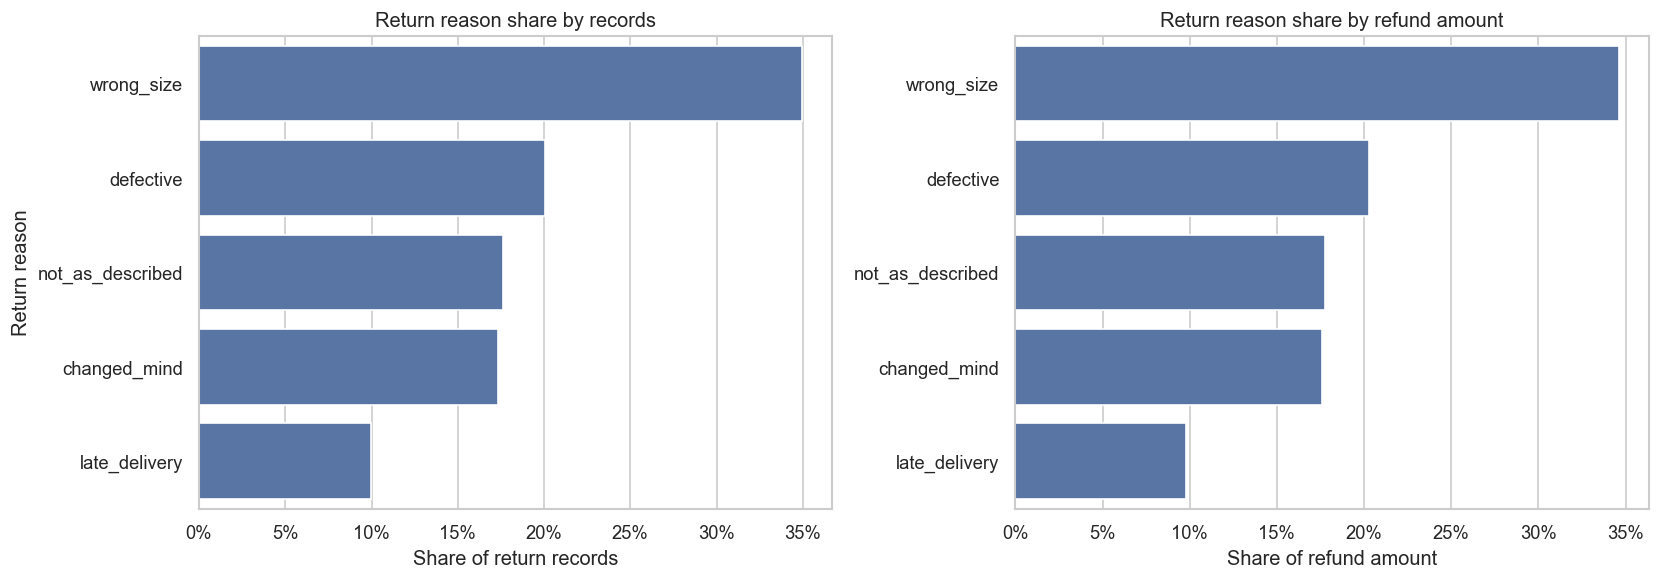

Top refund driver: wrong_size (35.0% of records, 34.6% of refund).


In [4]:
# =========================================
# 3) DIAGNOSTIC — Return reason distribution and refund contribution
# =========================================

reason_summary = (
    returns.groupby("return_reason", dropna=False)
    .agg(
        return_records=("return_id", "count"),
        refund_amount=("refund_amount", "sum"),
        avg_refund=("refund_amount", "mean"),
        return_quantity=("return_quantity", "sum"),
    )
    .reset_index()
)

reason_summary["record_share"] = reason_summary["return_records"] / reason_summary["return_records"].sum()
reason_summary["refund_share"] = reason_summary["refund_amount"] / reason_summary["refund_amount"].sum()
reason_summary = reason_summary.sort_values("refund_amount", ascending=False)

display(reason_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=reason_summary,
    y="return_reason",
    x="record_share",
    ax=axes[0]
)
axes[0].set_title("Return reason share by records")
axes[0].set_xlabel("Share of return records")
axes[0].set_ylabel("Return reason")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")

sns.barplot(
    data=reason_summary,
    y="return_reason",
    x="refund_share",
    ax=axes[1]
)
axes[1].set_title("Return reason share by refund amount")
axes[1].set_xlabel("Share of refund amount")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")

plt.tight_layout()
plt.show()

top_reason = reason_summary.iloc[0]
print(
    f"Top refund driver: {top_reason['return_reason']} "
    f"({top_reason['record_share']:.1%} of records, {top_reason['refund_share']:.1%} of refund)."
)


## 4) Hypothesis test — Is delivery delay the main driver?

We test whether delivery lead time is associated with higher overall return rate.

Definitions:

- `order_to_delivery_days = delivery_date − order_date`
- `late` = orders above the 75th percentile of delivery lead time
- Return is measured at **order level**, regardless of reason

If late delivery were the main return driver, return rate should increase meaningfully in slower delivery buckets.


Delivery lead-time thresholds
- Median delivery time (P50): 6 days
- 75th percentile delivery time (P75): 7 days
- Late delivery definition: delivery time > 7 days


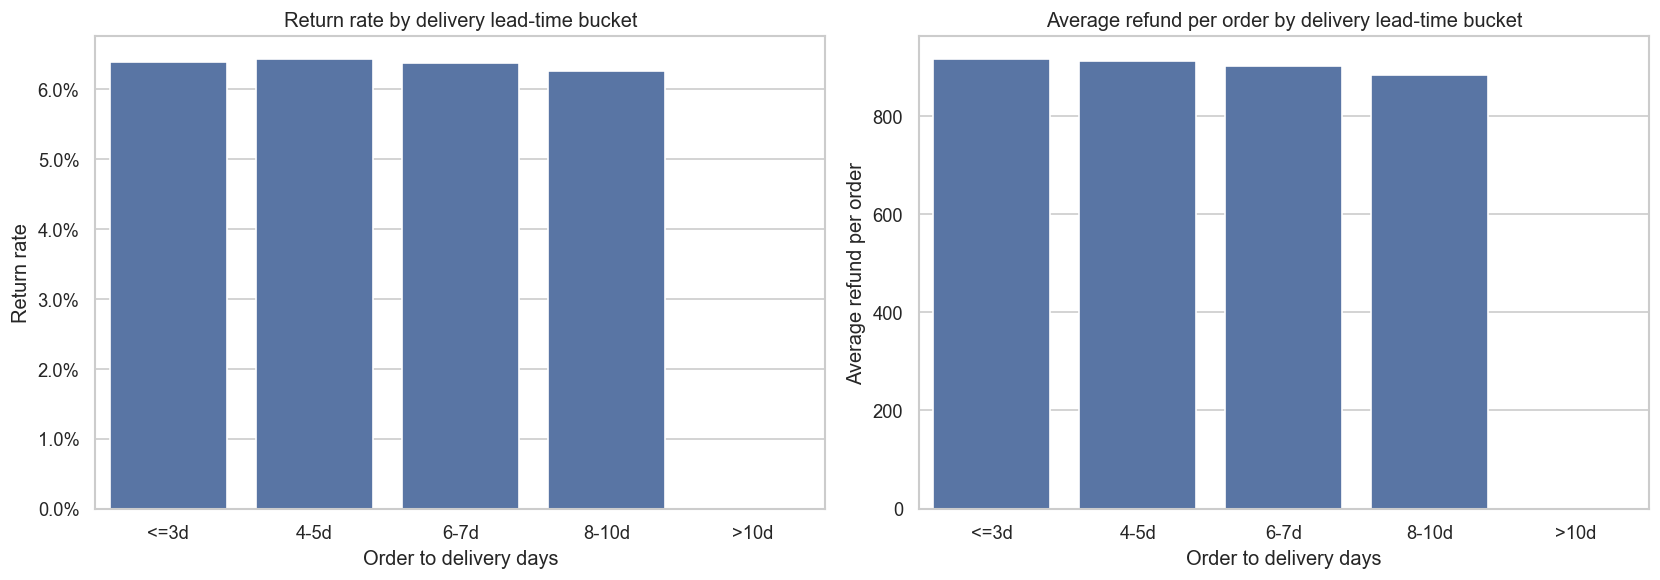

Return-rate comparison: on-time vs late delivery


,delivery_group,n_orders,avg_delivery_days,return_rate,avg_refund_per_order,refund_to_net
0,On-time (<=P75=7d),425017,5.111687,0.064054,908.075290,0.037525
1,Late (>P75=7d),141050,8.667040,0.062659,883.736766,0.036389


- On-time return rate: 6.41%
- Late return rate: 6.27%
- Difference, late minus on-time: -0.14%


In [5]:
# =========================================
# 4) DIAGNOSTIC — Delivery lead-time hypothesis
# =========================================

# Use only orders with valid delivery timestamps for the delivery-delay test.
delivery_df = base.dropna(subset=["order_to_delivery_days"]).copy()
delivery_df = delivery_df[delivery_df["order_to_delivery_days"] >= 0].copy()

p50_delivery = delivery_df["order_to_delivery_days"].quantile(0.50)
p75_delivery = delivery_df["order_to_delivery_days"].quantile(0.75)

# Definition used throughout the notebook.
delivery_df["is_late"] = delivery_df["order_to_delivery_days"] > p75_delivery

print("Delivery lead-time thresholds")
print(f"- Median delivery time (P50): {p50_delivery:.0f} days")
print(f"- 75th percentile delivery time (P75): {p75_delivery:.0f} days")
print(f"- Late delivery definition: delivery time > {p75_delivery:.0f} days")

# Bucketed view for diagnostic visualization.
delivery_bins = [-1, 3, 5, 7, 10, float("inf")]
delivery_labels = ["<=3d", "4-5d", "6-7d", "8-10d", ">10d"]

delivery_df["delivery_bucket"] = pd.cut(
    delivery_df["order_to_delivery_days"],
    bins=delivery_bins,
    labels=delivery_labels
)

bucket_stats = (
    delivery_df.groupby("delivery_bucket", observed=True)
    .agg(
        n_orders=("order_id", "nunique"),
        return_rate=("return_flag", "mean"),
        avg_delivery_days=("order_to_delivery_days", "mean"),
        avg_refund_per_order=("refund_total", "mean"),
        refund_total=("refund_total", "sum"),
        net_sales=("net_sales", "sum"),
    )
    .reset_index()
)

# Remove empty buckets and compute refund intensity safely.
bucket_stats = bucket_stats[bucket_stats["n_orders"] > 0].copy()
bucket_stats["refund_to_net"] = np.where(
    bucket_stats["net_sales"] > 0,
    bucket_stats["refund_total"] / bucket_stats["net_sales"],
    np.nan
)

# On-time vs late comparison.
late_comparison = (
    delivery_df.groupby("is_late")
    .agg(
        n_orders=("order_id", "nunique"),
        avg_delivery_days=("order_to_delivery_days", "mean"),
        return_rate=("return_flag", "mean"),
        avg_refund_per_order=("refund_total", "mean"),
        refund_total=("refund_total", "sum"),
        net_sales=("net_sales", "sum"),
    )
    .reset_index()
)
late_comparison["delivery_group"] = late_comparison["is_late"].map({
    False: f"On-time (<=P75={p75_delivery:.0f}d)",
    True: f"Late (>P75={p75_delivery:.0f}d)",
})
late_comparison["refund_to_net"] = late_comparison["refund_total"] / late_comparison["net_sales"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=bucket_stats, x="delivery_bucket", y="return_rate", ax=axes[0])
axes[0].set_title("Return rate by delivery lead-time bucket")
axes[0].set_xlabel("Order to delivery days")
axes[0].set_ylabel("Return rate")
axes[0].yaxis.set_major_formatter(lambda y, pos: f"{y*100:.1f}%")

sns.barplot(data=bucket_stats, x="delivery_bucket", y="avg_refund_per_order", ax=axes[1])
axes[1].set_title("Average refund per order by delivery lead-time bucket")
axes[1].set_xlabel("Order to delivery days")
axes[1].set_ylabel("Average refund per order")

plt.tight_layout()
plt.show()

print("Return-rate comparison: on-time vs late delivery")
display(late_comparison[[
    "delivery_group",
    "n_orders",
    "avg_delivery_days",
    "return_rate",
    "avg_refund_per_order",
    "refund_to_net",
]])

on_time_return_rate = late_comparison.loc[~late_comparison["is_late"], "return_rate"].iloc[0]
late_return_rate = late_comparison.loc[late_comparison["is_late"], "return_rate"].iloc[0]

print(f"- On-time return rate: {on_time_return_rate:.2%}")
print(f"- Late return rate: {late_return_rate:.2%}")
print(f"- Difference, late minus on-time: {(late_return_rate - on_time_return_rate):.2%}")


## 5) Predictive check — Is late-share a leading indicator of future returns?

We check whether monthly `late_share(t)` correlates with `return_rate(t+lag)` for lag 0–3 months.

This is not a causal model, but it helps decide whether late delivery is useful as a simple early-warning signal for overall returns.


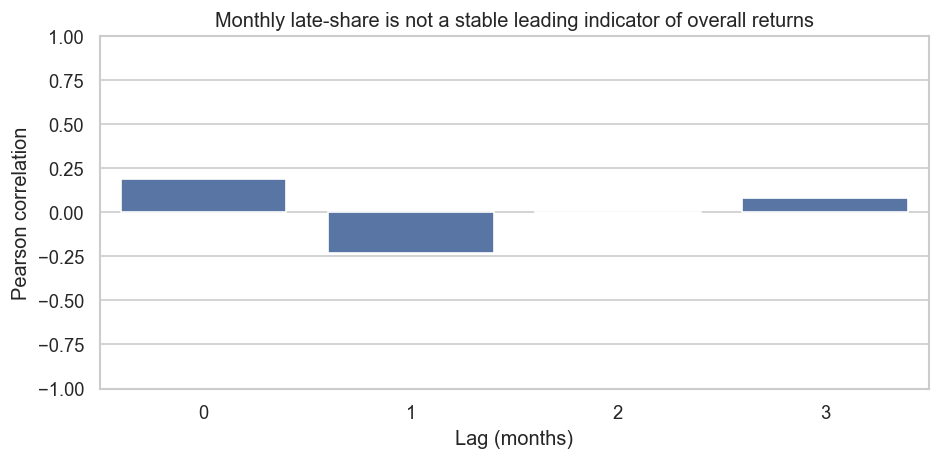

,lag_months,corr_late_share_t_return_rate_t_plus_lag
0,0,0.190935
1,1,-0.229556
2,2,-0.003222
3,3,0.083036


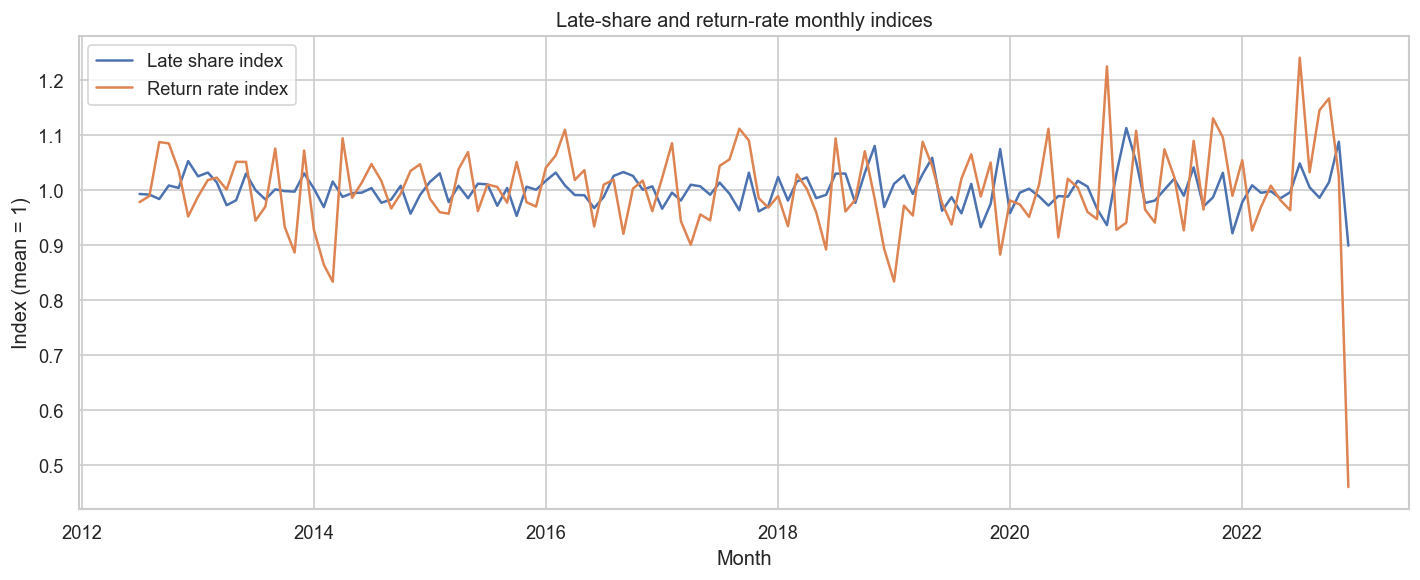

In [6]:
# =========================================
# 5) PREDICTIVE CHECK — monthly late-share vs future return rate
# =========================================

m = delivery_df.copy()
m["month"] = m["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_late = (
    m.groupby("month")
    .agg(
        late_share=("is_late", "mean"),
        return_rate=("return_flag", "mean"),
        n_orders=("order_id", "nunique"),
    )
    .reset_index()
    .sort_values("month")
)

rows = []
for lag in range(0, 4):
    corr = monthly_late["late_share"].corr(monthly_late["return_rate"].shift(-lag))
    rows.append({
        "lag_months": lag,
        "corr_late_share_t_return_rate_t_plus_lag": corr,
    })

corr_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=corr_df, x="lag_months", y="corr_late_share_t_return_rate_t_plus_lag", ax=ax)
ax.set_title("Monthly late-share is not a stable leading indicator of overall returns")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Pearson correlation")
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

display(corr_df)

# Optional visual overlay with normalized metrics for storytelling.
plot_monthly = monthly_late.copy()
plot_monthly["late_share_index"] = plot_monthly["late_share"] / plot_monthly["late_share"].mean()
plot_monthly["return_rate_index"] = plot_monthly["return_rate"] / plot_monthly["return_rate"].mean()

plt.figure(figsize=(12, 5))
plt.plot(plot_monthly["month"], plot_monthly["late_share_index"], label="Late share index")
plt.plot(plot_monthly["month"], plot_monthly["return_rate_index"], label="Return rate index")
plt.title("Late-share and return-rate monthly indices")
plt.xlabel("Month")
plt.ylabel("Index (mean = 1)")
plt.legend()
plt.tight_layout()
plt.show()


## 6) Drill-down — Where do `wrong_size` returns concentrate?

Because `wrong_size` is the largest refund driver in the current analysis, this section identifies where the intervention should focus.

We analyze `wrong_size` by:

- category
- segment
- size
- category-size combination

This turns the insight into an actionable recommendation: if the problem is concentrated in a few product groups, the business can prioritize size-chart improvements, fit notes, model-size references, and fit recommendation prompts for those groups first.


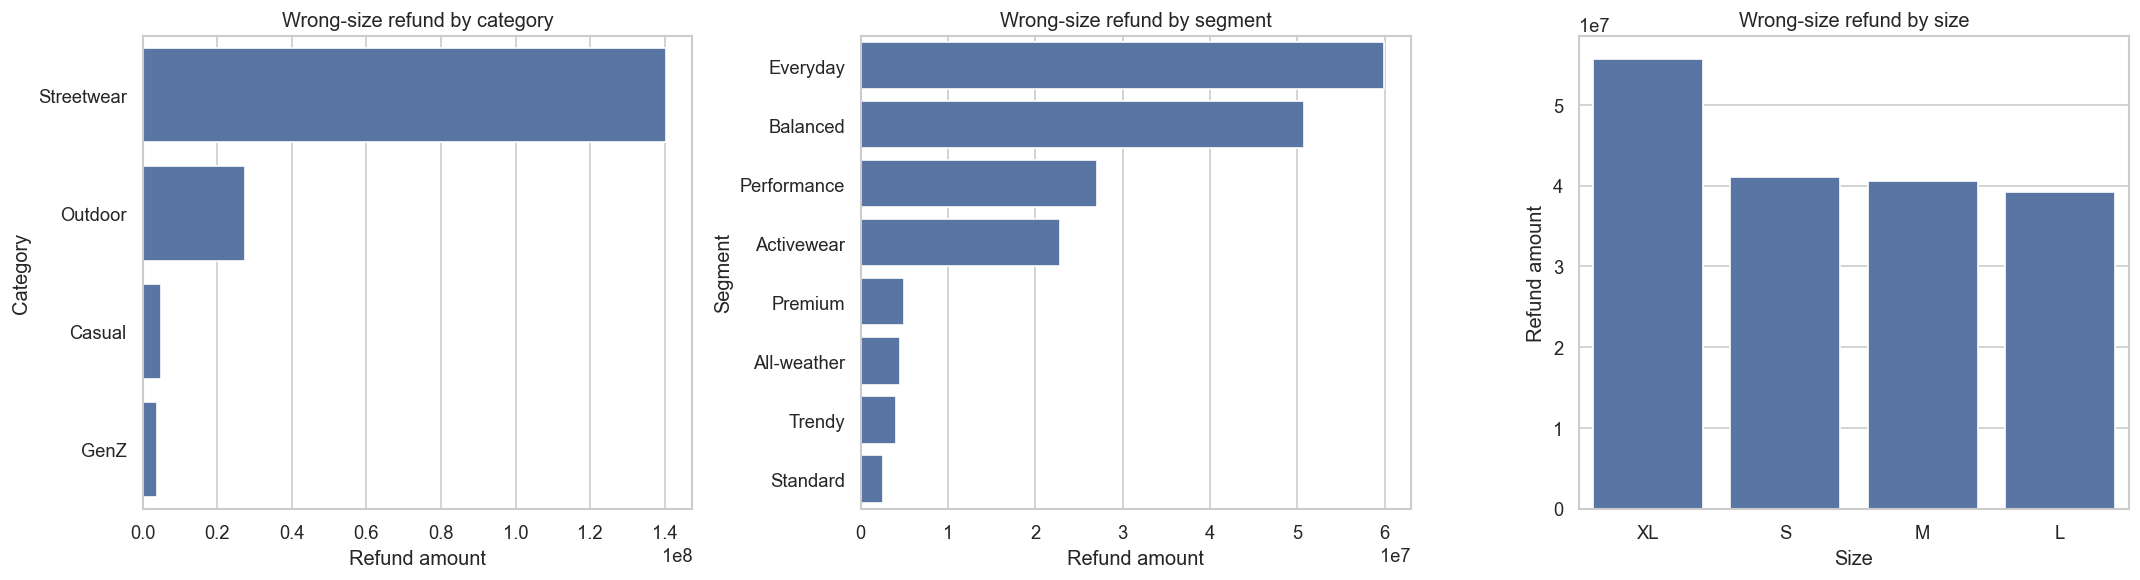

Top wrong_size categories:


,category,return_records,refund_amount,avg_refund
3,Streetwear,7626,1.403538e+08,18404.636625
2,Outdoor,5154,2.735592e+07,5307.706653
0,Casual,454,4.957854e+06,10920.383260
1,GenZ,733,4.019668e+06,5483.857790


Wrong_size by segment:


,segment,return_records,refund_amount,avg_refund
3,Everyday,3572,59965824.44,16787.744804
2,Balanced,1923,50790625.03,26412.181503
4,Performance,1926,27053404.85,14046.419964
0,Activewear,4591,22850101.97,4977.151377
5,Premium,591,4933806.12,8348.233706
1,All-weather,426,4529866.00,10633.488263
7,Trendy,733,4019667.76,5483.857790
6,Standard,205,2543904.58,12409.290634


Wrong_size by size:


,size,return_records,refund_amount,avg_refund
3,XL,3711,55712079.70,15012.686527
2,S,3372,41118540.70,12194.110528
1,M,3483,40611756.15,11659.993152
0,L,3401,39244824.20,11539.201470


Top category-size combinations for wrong_size refund:


,category,size,return_records,refund_amount,avg_refund
15,Streetwear,XL,2319,47191819.37,20350.073036
14,Streetwear,S,1858,32449294.51,17464.636442
13,Streetwear,M,1730,30563174.77,17666.575012
12,Streetwear,L,1719,30149470.25,17538.958842
8,Outdoor,L,1457,7348076.39,5043.291963
9,Outdoor,M,1383,7295363.95,5275.028163
11,Outdoor,XL,1190,6550242.06,5504.405092
10,Outdoor,S,1124,6162237.69,5482.417874
2,Casual,S,157,1713040.64,10911.086879
5,GenZ,M,225,1397021.97,6208.986533


In [7]:
# =========================================
# 6) DIAGNOSTIC DRILL-DOWN — wrong_size returns by product attributes
# =========================================

wrong_size = returns_prod[returns_prod["return_reason"].eq("wrong_size")].copy()

wrong_size_by_category = (
    wrong_size.groupby("category", dropna=False)
    .agg(
        return_records=("return_id", "count"),
        refund_amount=("refund_amount", "sum"),
        avg_refund=("refund_amount", "mean"),
    )
    .reset_index()
    .sort_values("refund_amount", ascending=False)
)

wrong_size_by_segment = (
    wrong_size.groupby("segment", dropna=False)
    .agg(
        return_records=("return_id", "count"),
        refund_amount=("refund_amount", "sum"),
        avg_refund=("refund_amount", "mean"),
    )
    .reset_index()
    .sort_values("refund_amount", ascending=False)
)

wrong_size_by_size = (
    wrong_size.groupby("size", dropna=False)
    .agg(
        return_records=("return_id", "count"),
        refund_amount=("refund_amount", "sum"),
        avg_refund=("refund_amount", "mean"),
    )
    .reset_index()
    .sort_values("refund_amount", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=wrong_size_by_category.head(10), y="category", x="refund_amount", ax=axes[0])
axes[0].set_title("Wrong-size refund by category")
axes[0].set_xlabel("Refund amount")
axes[0].set_ylabel("Category")

sns.barplot(data=wrong_size_by_segment, y="segment", x="refund_amount", ax=axes[1])
axes[1].set_title("Wrong-size refund by segment")
axes[1].set_xlabel("Refund amount")
axes[1].set_ylabel("Segment")

sns.barplot(data=wrong_size_by_size, x="size", y="refund_amount", ax=axes[2])
axes[2].set_title("Wrong-size refund by size")
axes[2].set_xlabel("Size")
axes[2].set_ylabel("Refund amount")

plt.tight_layout()
plt.show()

print("Top wrong_size categories:")
display(wrong_size_by_category.head(10))

print("Wrong_size by segment:")
display(wrong_size_by_segment)

print("Wrong_size by size:")
display(wrong_size_by_size)

# More granular: category-size combinations
wrong_size_cat_size = (
    wrong_size.groupby(["category", "size"], dropna=False)
    .agg(
        return_records=("return_id", "count"),
        refund_amount=("refund_amount", "sum"),
        avg_refund=("refund_amount", "mean"),
    )
    .reset_index()
    .sort_values("refund_amount", ascending=False)
)

print("Top category-size combinations for wrong_size refund:")
display(wrong_size_cat_size.head(15))



## 6.1) Deep dive — Is `wrong_size` a volume problem or a risk problem?

A large refund amount can happen for two different reasons:

1. **Volume effect:** the product group sells a lot, so it naturally also creates many returns.
2. **Risk effect:** the product group is over-represented in `wrong_size` returns relative to its sales exposure.

To separate these effects, we compare `wrong_size` refund share against sales share.

Key metrics:

- `wrong_size_refund_share`: share of total `wrong_size` refund generated by a group.
- `net_sales_share`: share of total net sales generated by the same group.
- `refund_concentration_index = wrong_size_refund_share / net_sales_share`.

Interpretation:

- index `> 1`: the group is over-represented in `wrong_size` refund loss.
- index `≈ 1`: refund loss is roughly proportional to sales volume.
- index `< 1`: the group sells a lot but is not disproportionately risky for `wrong_size`.

This makes the recommendation less obvious than “reduce wrong size”: it identifies **where** size-fit intervention should be prioritized.


In [8]:

# =========================================
# 6.1) DEEP DIVE — wrong_size concentration adjusted for sales exposure
# =========================================

from matplotlib.ticker import PercentFormatter, FuncFormatter

# Rebuild order-item table with product attributes for sales exposure.
product_cols_for_exposure = [
    "product_id", "product_name", "category", "segment", "size", "price", "cogs"
]

oi_prod_exposure = order_items_clean.merge(
    products[product_cols_for_exposure],
    on="product_id",
    how="left"
).copy()

# Sales-level financials by line.
oi_prod_exposure["gross_sales"] = oi_prod_exposure["quantity"] * oi_prod_exposure["unit_price"]
oi_prod_exposure["discount_amount"] = oi_prod_exposure["discount_amount"].fillna(0)
oi_prod_exposure["net_sales"] = (
    oi_prod_exposure["gross_sales"] - oi_prod_exposure["discount_amount"]
).clip(lower=0)

# Return-level table, already joined with product attributes.
returns_prod_deep = returns_prod.copy()
returns_prod_deep["refund_amount"] = pd.to_numeric(
    returns_prod_deep["refund_amount"], errors="coerce"
).fillna(0)
returns_prod_deep["return_quantity"] = pd.to_numeric(
    returns_prod_deep["return_quantity"], errors="coerce"
).fillna(0)

wrong_size_returns = returns_prod_deep[
    returns_prod_deep["return_reason"].eq("wrong_size")
].copy()

def summarize_wrong_size_by(dims):
    """
    Summarize wrong_size refund by product dimensions while controlling for sales exposure.
    dims: list[str], e.g. ["category", "size"].
    """
    sales = (
        oi_prod_exposure
        .groupby(dims, dropna=False)
        .agg(
            order_lines=("order_id", "size"),
            n_orders=("order_id", "nunique"),
            units_sold=("quantity", "sum"),
            gross_sales=("gross_sales", "sum"),
            net_sales=("net_sales", "sum"),
            avg_unit_price=("unit_price", "mean"),
            avg_discount_per_line=("discount_amount", "mean"),
        )
        .reset_index()
    )

    wr = (
        wrong_size_returns
        .groupby(dims, dropna=False)
        .agg(
            wrong_size_records=("return_id", "count"),
            wrong_size_return_qty=("return_quantity", "sum"),
            wrong_size_refund=("refund_amount", "sum"),
            avg_wrong_size_refund=("refund_amount", "mean"),
        )
        .reset_index()
    )

    out = sales.merge(wr, on=dims, how="left")

    for col in [
        "wrong_size_records",
        "wrong_size_return_qty",
        "wrong_size_refund",
        "avg_wrong_size_refund",
    ]:
        out[col] = out[col].fillna(0)

    total_wrong_refund = out["wrong_size_refund"].sum()
    total_net_sales = out["net_sales"].sum()

    out["wrong_size_refund_share"] = np.where(
        total_wrong_refund > 0,
        out["wrong_size_refund"] / total_wrong_refund,
        np.nan
    )
    out["net_sales_share"] = np.where(
        total_net_sales > 0,
        out["net_sales"] / total_net_sales,
        np.nan
    )
    out["refund_concentration_index"] = np.where(
        out["net_sales_share"] > 0,
        out["wrong_size_refund_share"] / out["net_sales_share"],
        np.nan
    )
    out["wrong_size_records_per_1k_lines"] = np.where(
        out["order_lines"] > 0,
        out["wrong_size_records"] / out["order_lines"] * 1000,
        np.nan
    )
    out["wrong_size_return_qty_rate"] = np.where(
        out["units_sold"] > 0,
        out["wrong_size_return_qty"] / out["units_sold"],
        np.nan
    )
    out["wrong_size_refund_to_net_sales"] = np.where(
        out["net_sales"] > 0,
        out["wrong_size_refund"] / out["net_sales"],
        np.nan
    )

    return out.sort_values("wrong_size_refund", ascending=False)


# Main exposure-adjusted tables.
wrong_size_category = summarize_wrong_size_by(["category"])
wrong_size_size = summarize_wrong_size_by(["size"])
wrong_size_segment = summarize_wrong_size_by(["segment"])
wrong_size_cat_size = summarize_wrong_size_by(["category", "size"])
wrong_size_cat_segment_size = summarize_wrong_size_by(["category", "segment", "size"])

# Display compact tables with the most useful columns.
cols_to_show = [
    "wrong_size_refund",
    "wrong_size_refund_share",
    "net_sales_share",
    "refund_concentration_index",
    "wrong_size_records_per_1k_lines",
    "wrong_size_return_qty_rate",
    "wrong_size_refund_to_net_sales",
    "order_lines",
    "units_sold",
    "net_sales",
]

print("Wrong_size by category — adjusted for sales exposure")
display(wrong_size_category[["category"] + cols_to_show].head(15))

print("Wrong_size by size — adjusted for sales exposure")
display(wrong_size_size[["size"] + cols_to_show].head(15))

print("Top category-size groups by wrong_size refund")
display(wrong_size_cat_size[["category", "size"] + cols_to_show].head(15))

# To avoid noisy tiny groups, keep only groups with meaningful sales exposure for risk ranking.
min_lines = max(100, int(wrong_size_cat_size["order_lines"].quantile(0.25)))
wrong_size_cat_size_valid = wrong_size_cat_size[
    wrong_size_cat_size["order_lines"] >= min_lines
].copy()

print(f"Top category-size groups by concentration index, among groups with at least {min_lines:,} order lines")
display(
    wrong_size_cat_size_valid
    .sort_values("refund_concentration_index", ascending=False)
    [["category", "size"] + cols_to_show]
    .head(15)
)


Wrong_size by category — adjusted for sales exposure


,category,wrong_size_refund,wrong_size_refund_share,net_sales_share,refund_concentration_index,wrong_size_records_per_1k_lines,wrong_size_return_qty_rate,wrong_size_refund_to_net_sales,order_lines,units_sold,net_sales
3,Streetwear,1.403538e+08,0.794363,0.800879,0.991864,19.378299,0.011728,0.011176,393533,1768826,1.255848e+10
2,Outdoor,2.735592e+07,0.154827,0.150081,1.031623,19.824144,0.011929,0.011624,259986,1170000,2.353397e+09
0,Casual,4.957854e+06,0.028060,0.028078,0.999366,18.923763,0.011566,0.011261,23991,107469,4.402852e+08
1,GenZ,4.019668e+06,0.022750,0.020962,1.085281,19.726042,0.012574,0.012229,37159,166848,3.287102e+08


Wrong_size by size — adjusted for sales exposure


,size,wrong_size_refund,wrong_size_refund_share,net_sales_share,refund_concentration_index,wrong_size_records_per_1k_lines,wrong_size_return_qty_rate,wrong_size_refund_to_net_sales,order_lines,units_sold,net_sales
3,XL,55712079.70,0.315315,0.316571,0.996031,19.225489,0.011688,0.011223,193025,867187,4.964113e+09
2,S,41118540.70,0.232719,0.228150,1.020028,19.599865,0.012077,0.011493,172042,774468,3.577589e+09
1,M,40611756.15,0.229851,0.222578,1.032678,19.741764,0.012038,0.011636,176428,792889,3.490213e+09
0,L,39244824.20,0.222115,0.232701,0.954507,19.639207,0.011569,0.010755,173174,778599,3.648954e+09


Top category-size groups by wrong_size refund


,category,size,wrong_size_refund,wrong_size_refund_share,net_sales_share,refund_concentration_index,wrong_size_records_per_1k_lines,wrong_size_return_qty_rate,wrong_size_refund_to_net_sales,order_lines,units_sold,net_sales
15,Streetwear,XL,47191819.37,0.267092,0.269308,0.991774,19.065863,0.011687,0.011175,121631,545712,4.222981e+09
14,Streetwear,S,32449294.51,0.183654,0.182401,1.006872,19.490601,0.011863,0.011345,95328,429397,2.860198e+09
13,Streetwear,M,30563174.77,0.172979,0.167747,1.031187,19.701853,0.012082,0.011619,87809,394881,2.630425e+09
12,Streetwear,L,30149470.25,0.170638,0.181423,0.940550,19.365741,0.011285,0.010598,88765,398836,2.844873e+09
8,Outdoor,L,7348076.39,0.041588,0.039857,1.043421,20.211969,0.012138,0.011757,72086,324360,6.249987e+08
9,Outdoor,M,7295363.95,0.041290,0.041049,1.005861,19.502221,0.011653,0.011334,70915,318024,6.436857e+08
11,Outdoor,XL,6550242.06,0.037073,0.036989,1.002262,19.384580,0.011499,0.011293,61389,276811,5.800175e+08
10,Outdoor,S,6162237.69,0.034877,0.032185,1.083614,20.217282,0.012484,0.012210,55596,250805,5.046949e+08
2,Casual,S,1713040.64,0.009695,0.008827,1.098364,19.102081,0.012287,0.012376,8219,36624,1.384160e+08
5,GenZ,M,1397021.97,0.007907,0.006340,1.247215,21.897810,0.014285,0.014053,10275,46482,9.940926e+07


Top category-size groups by concentration index, among groups with at least 8,021 order lines


,category,size,wrong_size_refund,wrong_size_refund_share,net_sales_share,refund_concentration_index,wrong_size_records_per_1k_lines,wrong_size_return_qty_rate,wrong_size_refund_to_net_sales,order_lines,units_sold,net_sales
5,GenZ,M,1397021.97,0.007907,0.006340,1.247215,21.897810,0.014285,0.014053,10275,46482,9.940926e+07
2,Casual,S,1713040.64,0.009695,0.008827,1.098364,19.102081,0.012287,0.012376,8219,36624,1.384160e+08
10,Outdoor,S,6162237.69,0.034877,0.032185,1.083614,20.217282,0.012484,0.012210,55596,250805,5.046949e+08
8,Outdoor,L,7348076.39,0.041588,0.039857,1.043421,20.211969,0.012138,0.011757,72086,324360,6.249987e+08
13,Streetwear,M,30563174.77,0.172979,0.167747,1.031187,19.701853,0.012082,0.011619,87809,394881,2.630425e+09
14,Streetwear,S,32449294.51,0.183654,0.182401,1.006872,19.490601,0.011863,0.011345,95328,429397,2.860198e+09
9,Outdoor,M,7295363.95,0.041290,0.041049,1.005861,19.502221,0.011653,0.011334,70915,318024,6.436857e+08
11,Outdoor,XL,6550242.06,0.037073,0.036989,1.002262,19.384580,0.011499,0.011293,61389,276811,5.800175e+08
15,Streetwear,XL,47191819.37,0.267092,0.269308,0.991774,19.065863,0.011687,0.011175,121631,545712,4.222981e+09
6,GenZ,S,793967.86,0.004494,0.004737,0.948627,18.063416,0.011762,0.010689,12899,57642,7.428011e+07



## 6.2) What explains the `wrong_size` concentration?

The goal is not only to find the largest refund bucket, but also to understand whether it is driven by:

- **sales scale**: large groups naturally create large refunds;
- **size-fit risk**: certain category-size groups have unusually high `wrong_size` refund relative to their sales exposure;
- **price/refund severity**: some groups may not return more often, but each wrong-size return costs more.

The following plots separate these effects.


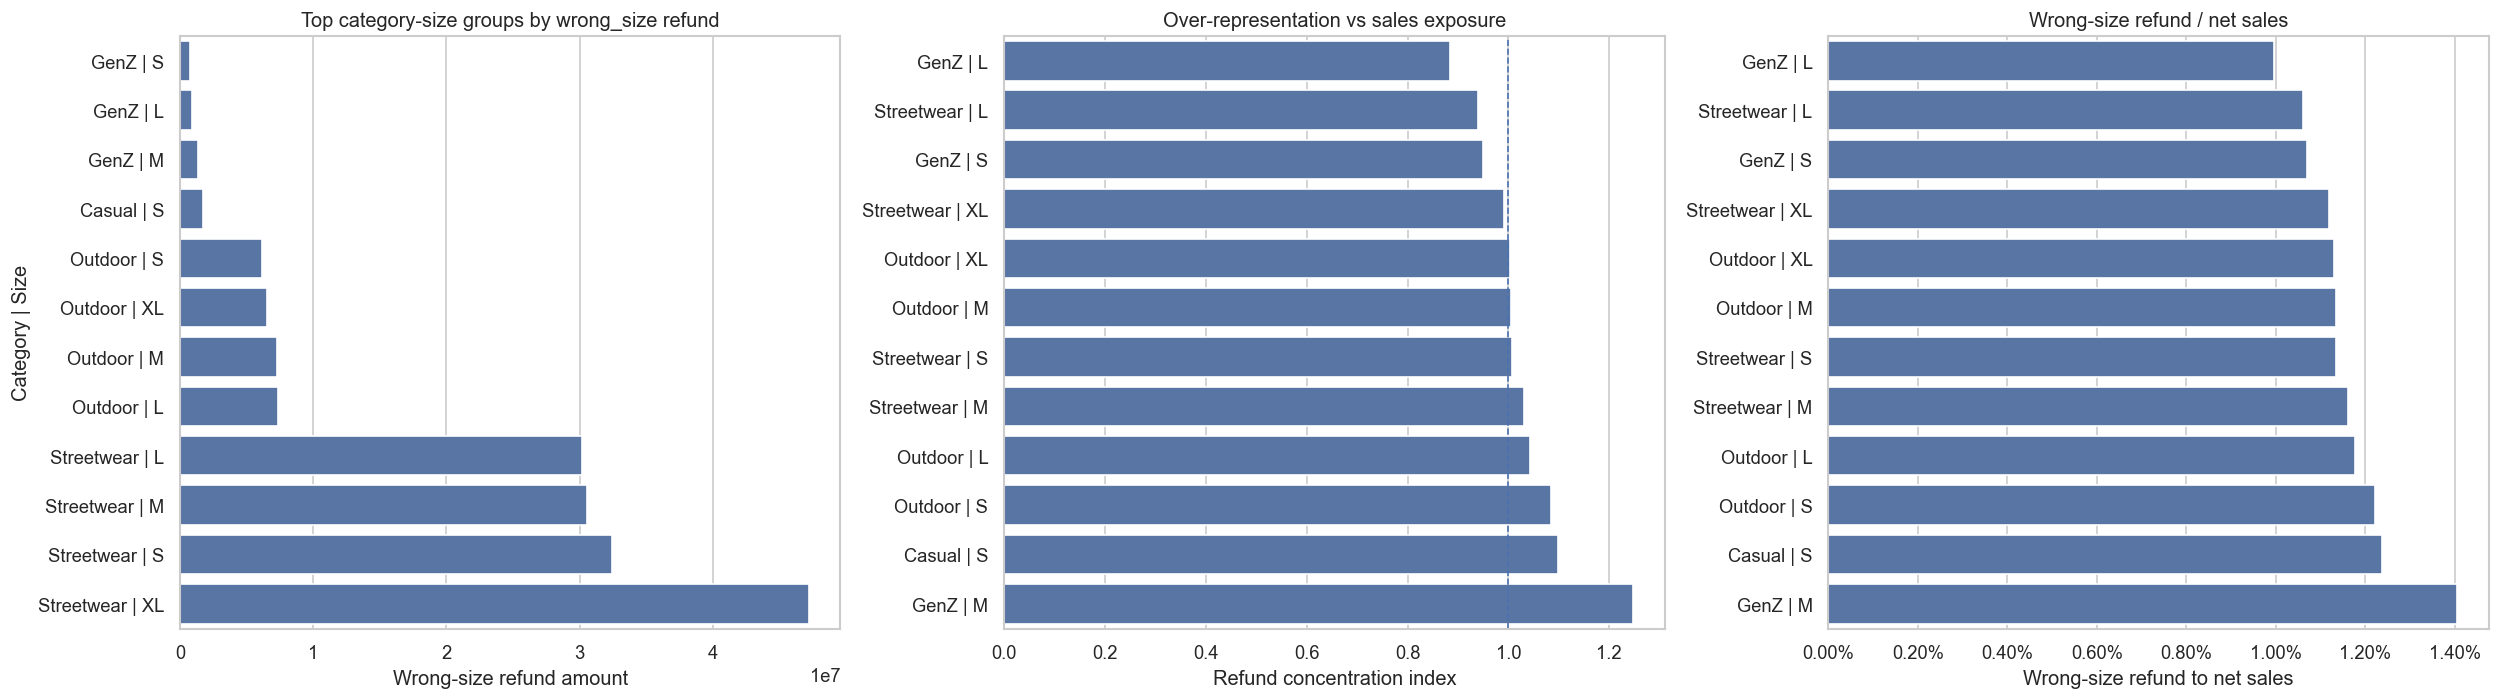

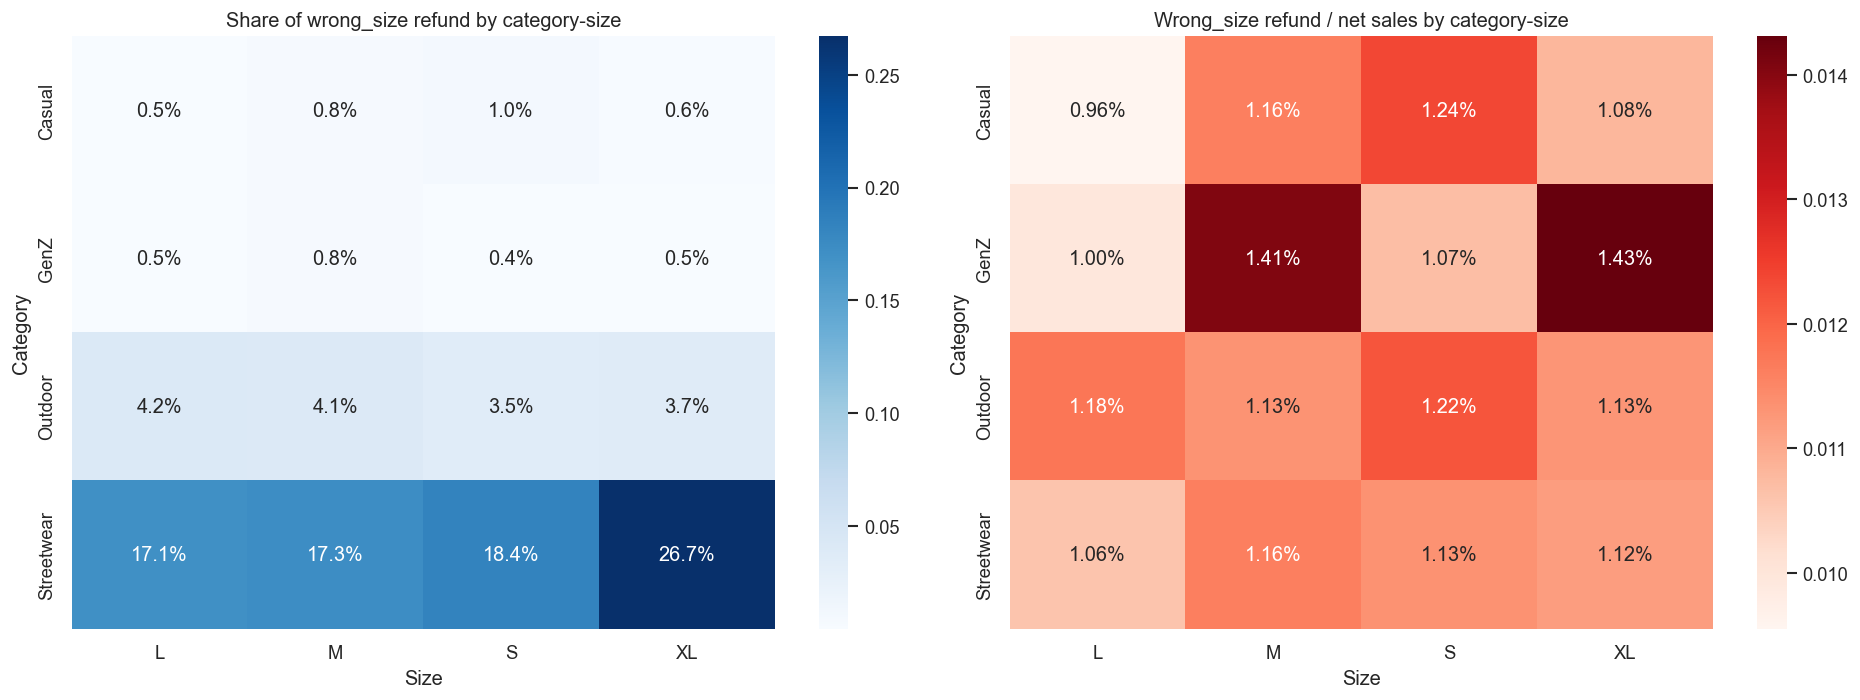

In [9]:

# =========================================
# 6.2) VISUALIZE — wrong_size concentration, risk, and severity
# =========================================

# Prepare display labels for category-size combinations.
plot_cs = wrong_size_cat_size_valid.copy()
plot_cs["category_size"] = (
    plot_cs["category"].astype(str) + " | " + plot_cs["size"].astype(str)
)

# Top groups by absolute refund loss.
top_refund_cs = plot_cs.sort_values("wrong_size_refund", ascending=False).head(12)

# Top groups by concentration index, among meaningful-volume groups.
top_lift_cs = plot_cs.sort_values("refund_concentration_index", ascending=False).head(12)

# Top groups by refund-to-net-sales ratio, another risk metric.
top_rate_cs = plot_cs.sort_values("wrong_size_refund_to_net_sales", ascending=False).head(12)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.barplot(
    data=top_refund_cs.sort_values("wrong_size_refund", ascending=True),
    y="category_size",
    x="wrong_size_refund",
    ax=axes[0]
)
axes[0].set_title("Top category-size groups by wrong_size refund")
axes[0].set_xlabel("Wrong-size refund amount")
axes[0].set_ylabel("Category | Size")

sns.barplot(
    data=top_lift_cs.sort_values("refund_concentration_index", ascending=True),
    y="category_size",
    x="refund_concentration_index",
    ax=axes[1]
)
axes[1].axvline(1.0, linestyle="--", linewidth=1)
axes[1].set_title("Over-representation vs sales exposure")
axes[1].set_xlabel("Refund concentration index")
axes[1].set_ylabel("")

sns.barplot(
    data=top_rate_cs.sort_values("wrong_size_refund_to_net_sales", ascending=True),
    y="category_size",
    x="wrong_size_refund_to_net_sales",
    ax=axes[2]
)
axes[2].set_title("Wrong-size refund / net sales")
axes[2].set_xlabel("Wrong-size refund to net sales")
axes[2].set_ylabel("")
axes[2].xaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# Heatmap 1: wrong-size refund share by category-size.
heat_refund = (
    wrong_size_cat_size
    .pivot_table(
        index="category",
        columns="size",
        values="wrong_size_refund_share",
        aggfunc="sum",
        fill_value=0
    )
)

# Heatmap 2: wrong-size refund to net sales by category-size.
heat_rate = (
    wrong_size_cat_size
    .pivot_table(
        index="category",
        columns="size",
        values="wrong_size_refund_to_net_sales",
        aggfunc="mean",
        fill_value=np.nan
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    heat_refund,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Share of wrong_size refund by category-size")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Category")

sns.heatmap(
    heat_rate,
    annot=True,
    fmt=".2%",
    cmap="Reds",
    ax=axes[1]
)
axes[1].set_title("Wrong_size refund / net sales by category-size")
axes[1].set_xlabel("Size")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()



## 6.3) Targeted intervention scenario

A broad recommendation such as “reduce wrong size” is too generic. A better business recommendation is:

> Prioritize the category-size groups that explain the largest share of `wrong_size` refund loss and/or are over-represented relative to their sales exposure.

This section estimates how much refund saving can be captured by targeting the top groups first.


,target_top_n_category_size_groups,covered_wrong_size_refund,covered_wrong_size_refund_share,covered_net_sales,covered_net_sales_share,saving_if_20pct_reduction
0,3,1.102043e+08,0.623725,9.713604e+09,0.619456,2.204086e+07
1,5,1.477018e+08,0.835951,1.318348e+10,0.840736,2.954037e+07
2,10,1.708197e+08,0.966792,1.514970e+10,0.966126,3.416395e+07


Top 5 target groups for a size-fit intervention


,category,size,wrong_size_refund,wrong_size_refund_share,net_sales_share,refund_concentration_index,wrong_size_refund_to_net_sales,saving_if_20pct_reduction,order_lines,units_sold
15,Streetwear,XL,47191819.37,0.267092,0.269308,0.991774,0.011175,9438363.874,121631,545712
14,Streetwear,S,32449294.51,0.183654,0.182401,1.006872,0.011345,6489858.902,95328,429397
13,Streetwear,M,30563174.77,0.172979,0.167747,1.031187,0.011619,6112634.954,87809,394881
12,Streetwear,L,30149470.25,0.170638,0.181423,0.940550,0.010598,6029894.050,88765,398836
8,Outdoor,L,7348076.39,0.041588,0.039857,1.043421,0.011757,1469615.278,72086,324360


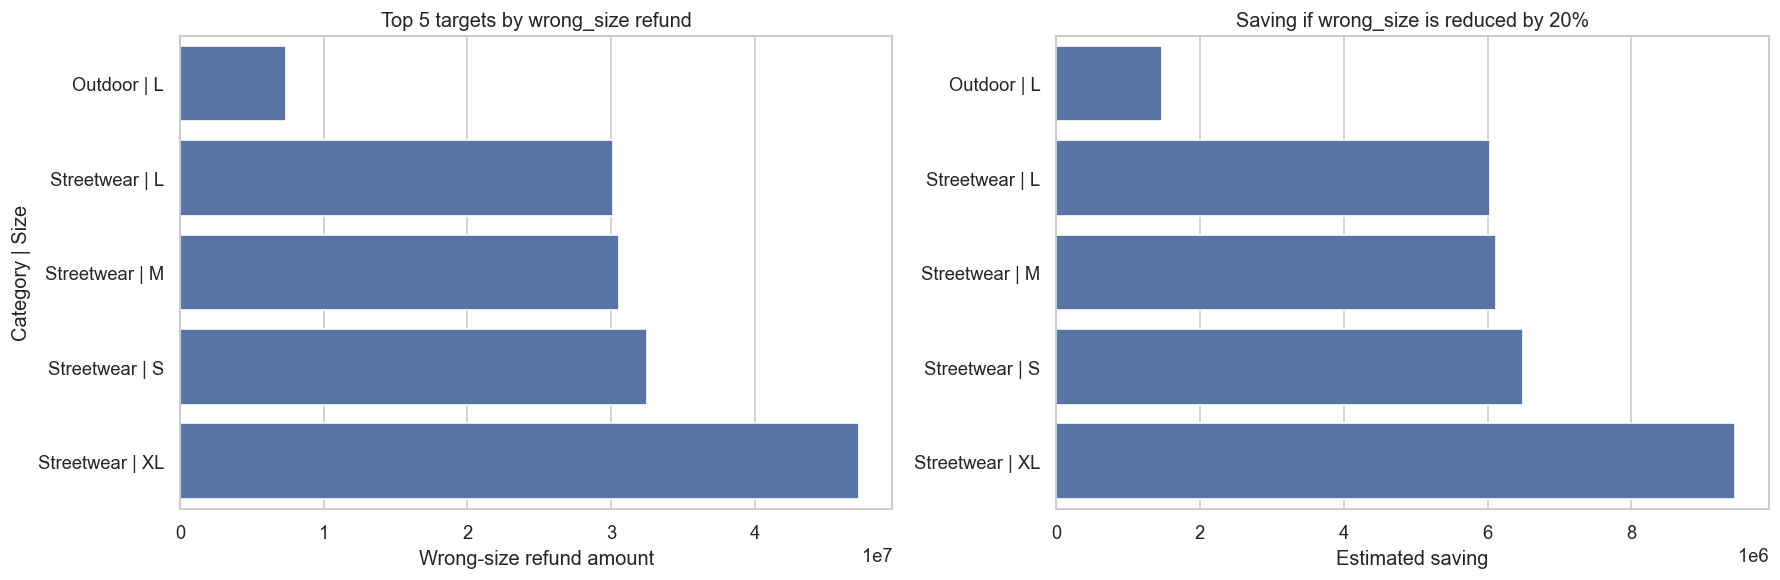

Targeted recommendation summary
- Top 5 category-size groups cover 83.6% of wrong_size refund while representing 84.1% of net sales.
- Reducing wrong_size in these top 5 groups by 20% would save 29.5 million monetary units.


In [10]:

# =========================================
# 6.3) PRESCRIPTIVE — targeted intervention on top category-size groups
# =========================================

# Rank by absolute refund loss because this is the most direct financial opportunity.
target_rank = wrong_size_cat_size_valid.sort_values("wrong_size_refund", ascending=False).copy()
target_rank["category_size"] = (
    target_rank["category"].astype(str) + " | " + target_rank["size"].astype(str)
)

total_wrong_size_refund = wrong_size_returns["refund_amount"].sum()
total_net_sales = oi_prod_exposure["net_sales"].sum()

scenario_rows = []
for n in [3, 5, 10]:
    selected = target_rank.head(n)
    targeted_refund = selected["wrong_size_refund"].sum()
    targeted_sales = selected["net_sales"].sum()
    scenario_rows.append({
        "target_top_n_category_size_groups": n,
        "covered_wrong_size_refund": targeted_refund,
        "covered_wrong_size_refund_share": targeted_refund / total_wrong_size_refund,
        "covered_net_sales": targeted_sales,
        "covered_net_sales_share": targeted_sales / total_net_sales,
        "saving_if_20pct_reduction": targeted_refund * 0.20,
    })

target_scenarios = pd.DataFrame(scenario_rows)

display(target_scenarios)

top5_target = target_rank.head(5).copy()
top5_target["saving_if_20pct_reduction"] = top5_target["wrong_size_refund"] * 0.20

print("Top 5 target groups for a size-fit intervention")
display(
    top5_target[
        [
            "category",
            "size",
            "wrong_size_refund",
            "wrong_size_refund_share",
            "net_sales_share",
            "refund_concentration_index",
            "wrong_size_refund_to_net_sales",
            "saving_if_20pct_reduction",
            "order_lines",
            "units_sold",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=top5_target.sort_values("wrong_size_refund", ascending=True),
    y="category_size",
    x="wrong_size_refund",
    ax=axes[0]
)
axes[0].set_title("Top 5 targets by wrong_size refund")
axes[0].set_xlabel("Wrong-size refund amount")
axes[0].set_ylabel("Category | Size")

sns.barplot(
    data=top5_target.sort_values("saving_if_20pct_reduction", ascending=True),
    y="category_size",
    x="saving_if_20pct_reduction",
    ax=axes[1]
)
axes[1].set_title("Saving if wrong_size is reduced by 20%")
axes[1].set_xlabel("Estimated saving")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Compact sentence for the report.
top5_saving = top5_target["saving_if_20pct_reduction"].sum()
top5_refund_share = top5_target["wrong_size_refund"].sum() / total_wrong_size_refund
top5_sales_share = top5_target["net_sales"].sum() / total_net_sales

print("Targeted recommendation summary")
print(
    f"- Top 5 category-size groups cover {top5_refund_share:.1%} of wrong_size refund "
    f"while representing {top5_sales_share:.1%} of net sales."
)
print(
    f"- Reducing wrong_size in these top 5 groups by 20% would save "
    f"{top5_saving / 1_000_000:.1f} million monetary units."
)



## 6.4) Export deep-dive figure for LaTeX

This optional figure is useful if the report has enough space for a more specific recommendation. It shows:

1. where `wrong_size` refund is concentrated;
2. which category-size groups are over-represented relative to sales;
3. the saving potential from targeting the top 5 groups.


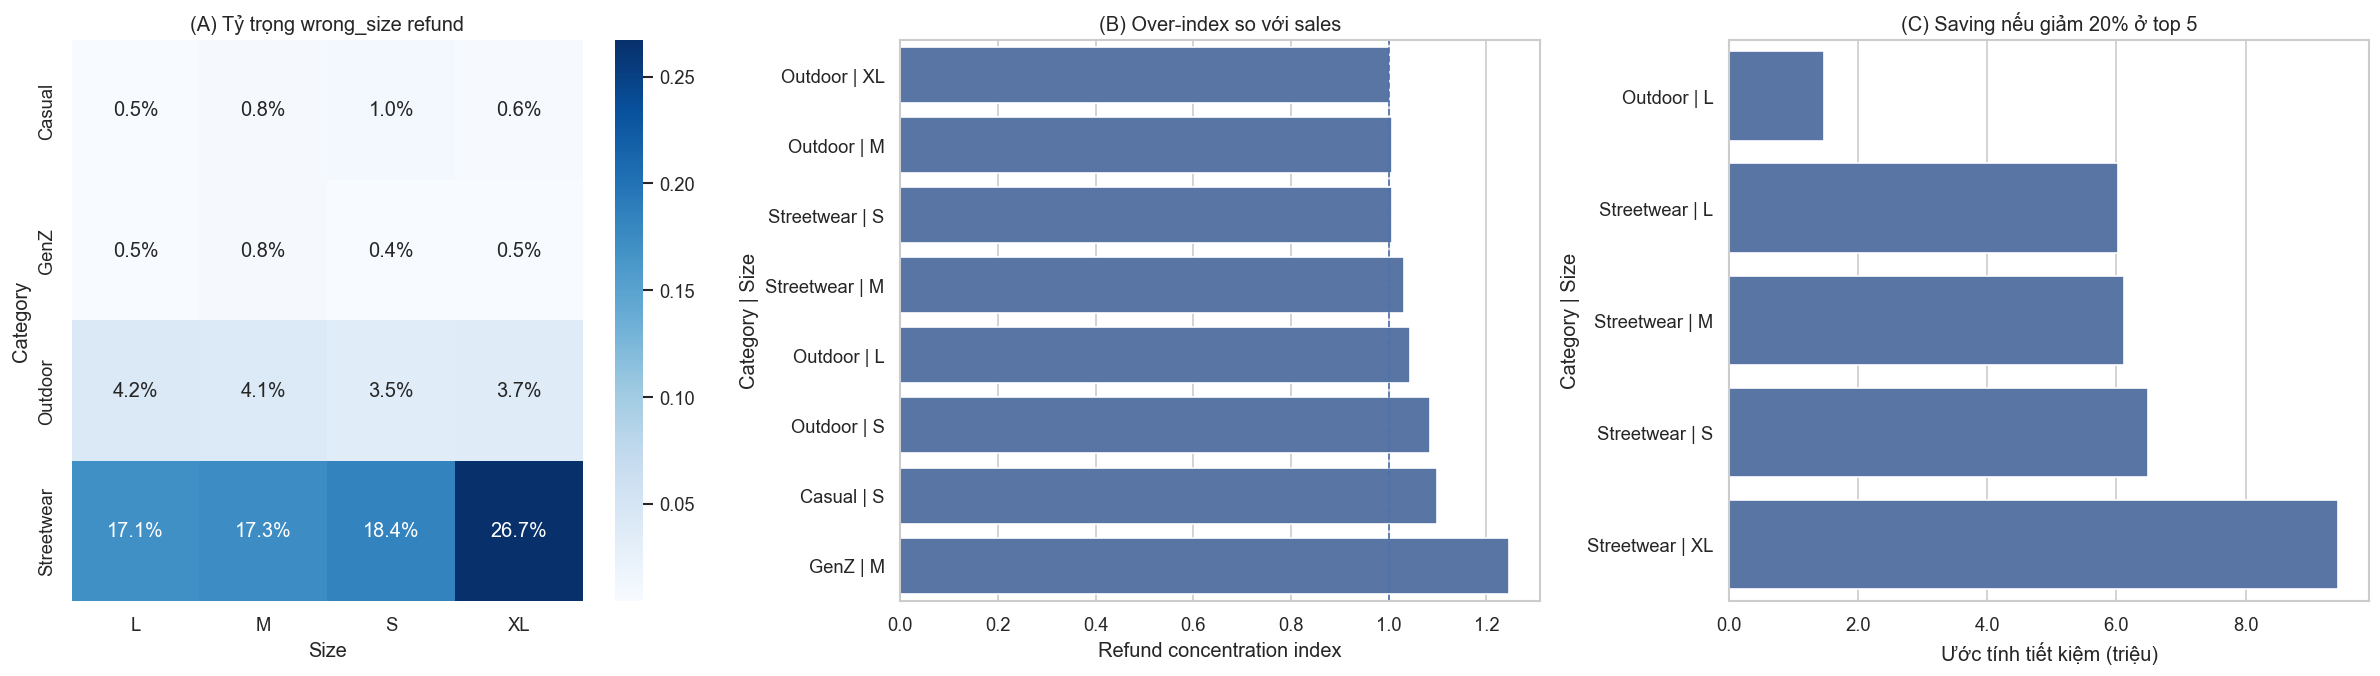

In [13]:

# =========================================
# EXPORT OPTIONAL DEEP-DIVE FIGURE FOR LATEX — INSIGHT 3
# =========================================
import os
os.makedirs("figures", exist_ok=True)

# Panel A: heatmap of wrong_size refund share.
heat_refund = (
    wrong_size_cat_size
    .pivot_table(
        index="category",
        columns="size",
        values="wrong_size_refund_share",
        aggfunc="sum",
        fill_value=0
    )
)

# Panel B: top concentration index.
top_lift_plot = (
    wrong_size_cat_size_valid
    .copy()
    .sort_values("refund_concentration_index", ascending=False)
    .head(8)
)
top_lift_plot["category_size"] = (
    top_lift_plot["category"].astype(str) + " | " + top_lift_plot["size"].astype(str)
)

# Panel C: top 5 targeted saving.
target_plot = top5_target.copy()
target_plot["category_size"] = (
    target_plot["category"].astype(str) + " | " + target_plot["size"].astype(str)
)
target_plot["saving_20pct_million"] = target_plot["saving_if_20pct_reduction"] / 1_000_000

fig, axes = plt.subplots(1, 3, figsize=(20, 5.8))

sns.heatmap(
    heat_refund,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("(A) Tỷ trọng wrong_size refund")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Category")

sns.barplot(
    data=top_lift_plot.sort_values("refund_concentration_index", ascending=True),
    y="category_size",
    x="refund_concentration_index",
    ax=axes[1]
)
axes[1].axvline(1.0, linestyle="--", linewidth=1)
axes[1].set_title("(B) Over-index so với sales")
axes[1].set_xlabel("Refund concentration index")
axes[1].set_ylabel("Category | Size")

sns.barplot(
    data=target_plot.sort_values("saving_20pct_million", ascending=True),
    y="category_size",
    x="saving_20pct_million",
    ax=axes[2]
)
axes[2].set_title("(C) Saving nếu giảm 20% ở top 5")
axes[2].set_xlabel("Ước tính tiết kiệm (triệu)")
axes[2].set_ylabel("Category | Size")
axes[2].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))

plt.tight_layout()
plt.savefig(
    "figures/insight3_wrong_size_deepdive.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



## 6.5) Deep-dive takeaway

The deeper analysis improves the original insight in three ways:

1. It separates **sales volume** from **size-fit risk** using the refund concentration index.
2. It identifies specific category-size groups where `wrong_size` interventions should be prioritized.
3. It turns the recommendation from a generic action into a targeted rollout plan: start with the highest-refund and most over-indexed category-size groups, then expand if the intervention works.

This makes the business recommendation less obvious than “reduce wrong-size returns” and more useful for resource allocation.


## 7) Region check — Is this a geography/logistics issue?

This quick check tests whether the return problem is geographically concentrated. If regions show similar delivery lead times, late-delivery shares, and return rates, this further weakens the hypothesis that overall returns are primarily driven by logistics differences across regions.


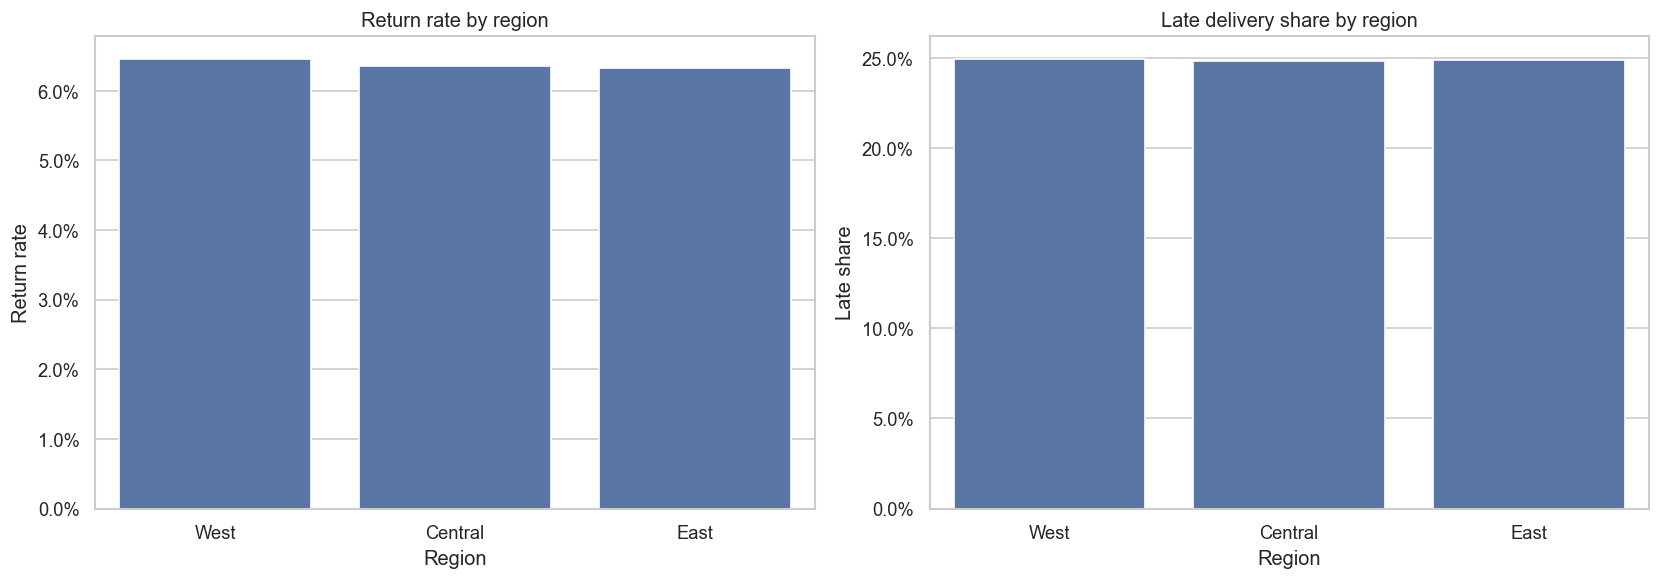

,region,n_orders,return_rate,late_share,avg_delivery_days,refund_total,net_sales,refund_to_net
2,West,146923,0.064626,0.249763,5.998788,1.237297e+08,3.215414e+09,0.038480
0,Central,161388,0.063573,0.248457,5.996301,1.513871e+08,4.120335e+09,0.036741
1,East,257756,0.063265,0.249290,5.997723,2.354817e+08,6.374931e+09,0.036939


In [14]:
# =========================================
# 7) REGION CHECK — delivery and returns by region
# =========================================

region_df = delivery_df.dropna(subset=["region"]).copy()

region_stats = (
    region_df.groupby("region")
    .agg(
        n_orders=("order_id", "nunique"),
        return_rate=("return_flag", "mean"),
        late_share=("is_late", "mean"),
        avg_delivery_days=("order_to_delivery_days", "mean"),
        refund_total=("refund_total", "sum"),
        net_sales=("net_sales", "sum"),
    )
    .reset_index()
)

region_stats["refund_to_net"] = region_stats["refund_total"] / region_stats["net_sales"]
region_stats = region_stats.sort_values("return_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_stats, x="region", y="return_rate", ax=axes[0])
axes[0].set_title("Return rate by region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Return rate")
axes[0].yaxis.set_major_formatter(lambda y, pos: f"{y*100:.1f}%")

sns.barplot(data=region_stats, x="region", y="late_share", ax=axes[1])
axes[1].set_title("Late delivery share by region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Late share")
axes[1].yaxis.set_major_formatter(lambda y, pos: f"{y*100:.1f}%")

plt.tight_layout()
plt.show()

display(region_stats)


## 8) Prescriptive — What-if by return reason

Instead of using late delivery as the main saving lever, we estimate refund saving from reducing the largest return reasons by 10%, 20%, and 30%.

This is directly aligned with business action:

- `wrong_size` → better size chart, fit recommender, fit notes, exchange-first policy
- `defective` → category-level QC and supplier/vendor monitoring
- `not_as_described` → better product images, material details, size model photos, expectation setting
- `changed_mind` → product comparison, recommendation quality, post-purchase nudges


,return_reason,return_records,record_share,refund_amount,refund_share,saving_if_reduce_10pct,saving_if_reduce_20pct,saving_if_reduce_30pct
4,wrong_size,13967,0.349708,1.766872e+08,0.346039,1.766872e+07,3.533744e+07,5.300616e+07
1,defective,8020,0.200806,1.035991e+08,0.202897,1.035991e+07,2.071983e+07,3.107974e+07
3,not_as_described,7035,0.176144,9.065319e+07,0.177543,9.065319e+06,1.813064e+07,2.719596e+07
0,changed_mind,6931,0.173540,8.972176e+07,0.175719,8.972176e+06,1.794435e+07,2.691653e+07
2,late_delivery,3986,0.099802,4.993721e+07,0.097801,4.993721e+06,9.987443e+06,1.498116e+07


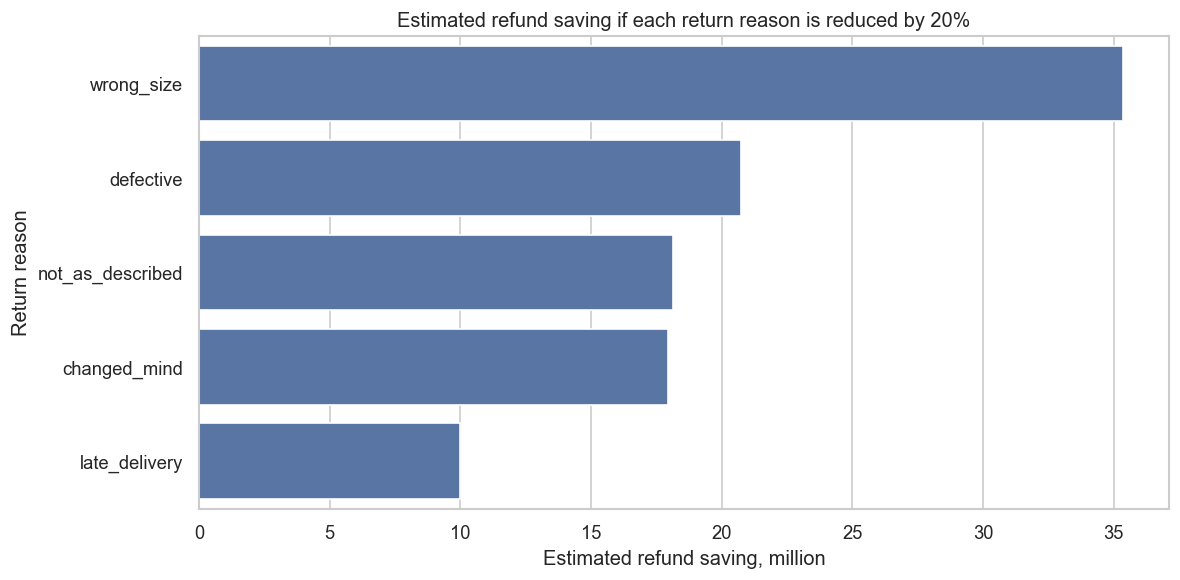

Highest-impact intervention target: wrong_size with estimated 20% reduction saving = 35.3 million.

Observed-mix delivery what-if:


,intervention,expected_return_reduction,expected_refund_saving,expected_refund_saving_million
0,Reduce late-share by 10%,-19.680378,-278652.649206,-0.278653
1,Reduce late-share by 20%,-39.360757,-557305.298413,-0.557305
2,Reduce late-share by 30%,-59.041135,-835957.947619,-0.835958


In [15]:
# =========================================
# 8) PRESCRIPTIVE — what-if saving by return reason
# =========================================

reason_impact = reason_summary.copy()

for pct in [0.10, 0.20, 0.30]:
    col_name = f"saving_if_reduce_{int(pct * 100)}pct"
    reason_impact[col_name] = reason_impact["refund_amount"] * pct

reason_impact = reason_impact.sort_values("saving_if_reduce_20pct", ascending=False)

display_cols = [
    "return_reason",
    "return_records",
    "record_share",
    "refund_amount",
    "refund_share",
    "saving_if_reduce_10pct",
    "saving_if_reduce_20pct",
    "saving_if_reduce_30pct",
]

display(reason_impact[display_cols])

# Plot 20% reduction scenario for top reasons.
plot_impact = reason_impact.sort_values("saving_if_reduce_20pct", ascending=False).copy()
plot_impact["saving_if_reduce_20pct_million"] = plot_impact["saving_if_reduce_20pct"] / 1_000_000

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_impact, y="return_reason", x="saving_if_reduce_20pct_million")
plt.title("Estimated refund saving if each return reason is reduced by 20%")
plt.xlabel("Estimated refund saving, million")
plt.ylabel("Return reason")
plt.tight_layout()
plt.show()

top_saving = plot_impact.iloc[0]
print(
    f"Highest-impact intervention target: {top_saving['return_reason']} "
    f"with estimated 20% reduction saving = "
    f"{top_saving['saving_if_reduce_20pct'] / 1_000_000:,.1f} million."
)

# Compare against delivery-late lever from observed mix.
on_time = delivery_df[~delivery_df["is_late"]]
late = delivery_df[delivery_df["is_late"]]

p_return_ontime = on_time["return_flag"].mean()
p_return_late = late["return_flag"].mean()
late_share = delivery_df["is_late"].mean()
avg_refund_per_returned_order = delivery_df.loc[delivery_df["return_flag"], "refund_total"].mean()
N = delivery_df["order_id"].nunique()

delivery_scenarios = []
for reduce_frac in [0.10, 0.20, 0.30]:
    new_late_share = late_share * (1 - reduce_frac)
    base_expected_return_prob = late_share * p_return_late + (1 - late_share) * p_return_ontime
    new_expected_return_prob = new_late_share * p_return_late + (1 - new_late_share) * p_return_ontime
    expected_return_reduction = N * (base_expected_return_prob - new_expected_return_prob)
    expected_refund_saving = expected_return_reduction * avg_refund_per_returned_order

    delivery_scenarios.append({
        "intervention": f"Reduce late-share by {int(reduce_frac*100)}%",
        "expected_return_reduction": expected_return_reduction,
        "expected_refund_saving": expected_refund_saving,
        "expected_refund_saving_million": expected_refund_saving / 1_000_000,
    })

delivery_scenarios = pd.DataFrame(delivery_scenarios)
print("\nObserved-mix delivery what-if:")
display(delivery_scenarios)


## 8.1) Export figure for LaTeX report

This cell creates a single 3-panel figure for the one-page report section:

- Panel A: refund share by return reason.
- Panel B: return rate by delivery lead-time bucket.
- Panel C: estimated refund saving if each reason is reduced by 20%.

The exported file is saved as `figures/insight3_refund_reduction.png`.


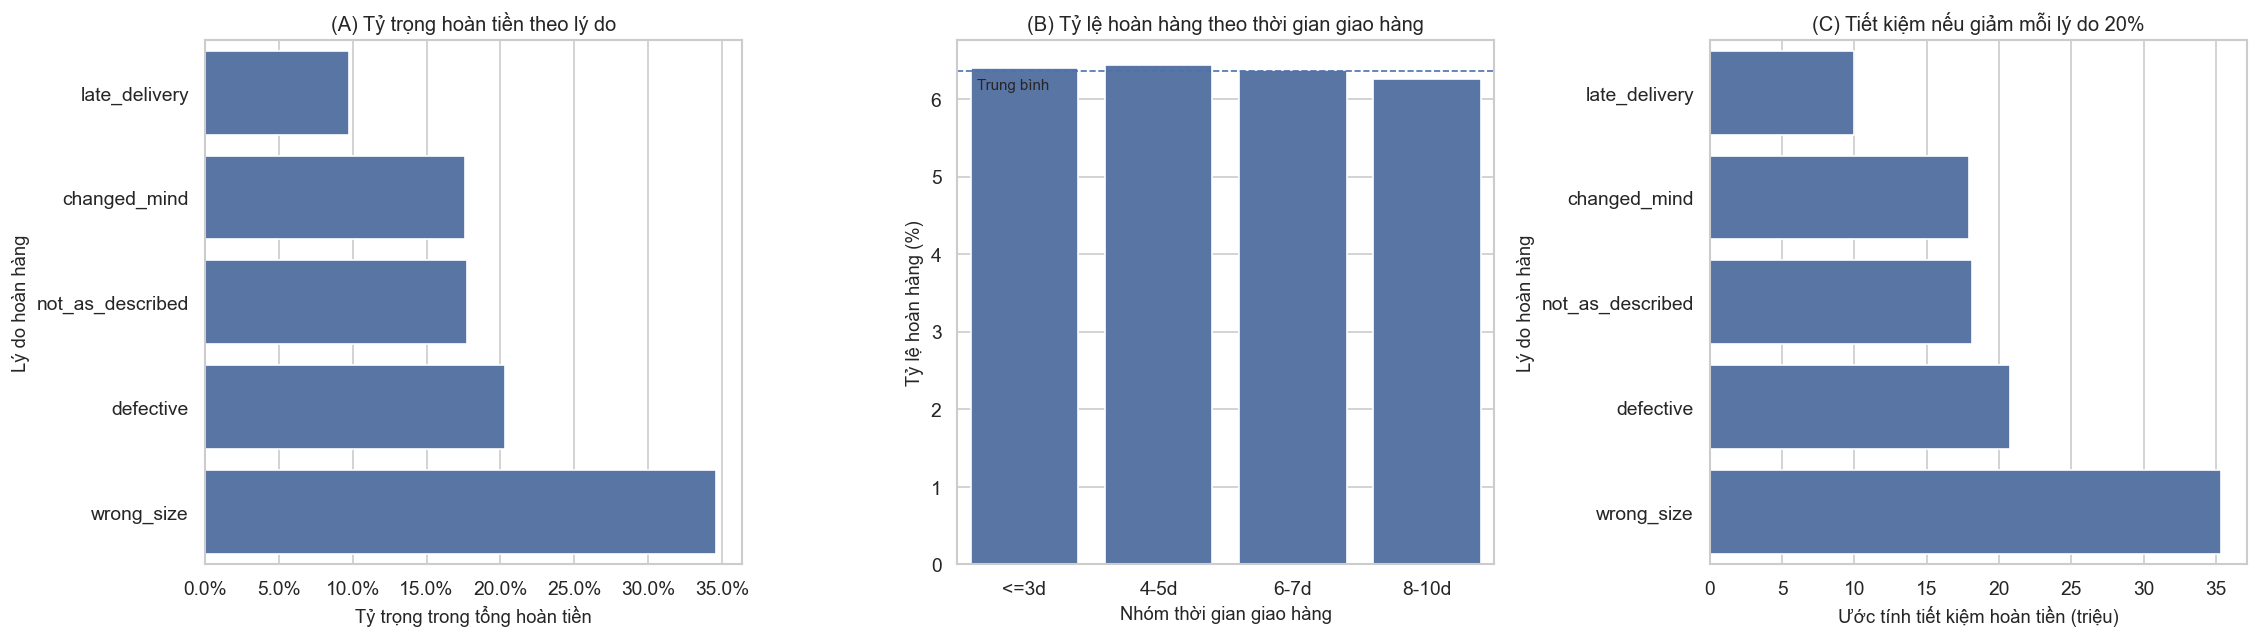

In [16]:
# =========================================
# EXPORT FIGURE FOR LATEX REPORT — INSIGHT 3
# Final cleaned version for Vietnamese report
# =========================================

import os
from matplotlib.ticker import PercentFormatter, FuncFormatter

os.makedirs("figures", exist_ok=True)

# -----------------------------
# Panel A: refund share by return reason
# -----------------------------
plot_reason = reason_summary.sort_values("refund_share", ascending=True).copy()

# -----------------------------
# Panel B: return rate by delivery bucket
# -----------------------------
plot_bucket = bucket_stats.copy()
plot_bucket["return_rate_pct"] = plot_bucket["return_rate"] * 100

# Remove buckets without a meaningful return-rate value.
plot_bucket = plot_bucket.dropna(subset=["return_rate_pct"])

# Keep the bucket order stable.
bucket_order = ["<=3d", "4-5d", "6-7d", "8-10d", ">10d"]
plot_bucket["delivery_bucket"] = plot_bucket["delivery_bucket"].astype(str)
plot_bucket = plot_bucket[plot_bucket["delivery_bucket"].isin(bucket_order)].copy()
plot_bucket["delivery_bucket"] = pd.Categorical(
    plot_bucket["delivery_bucket"],
    categories=bucket_order,
    ordered=True
)
plot_bucket = plot_bucket.sort_values("delivery_bucket")

bucket_order_present = [
    bucket for bucket in bucket_order
    if bucket in plot_bucket["delivery_bucket"].astype(str).unique()
]

# -----------------------------
# Panel C: estimated saving if reducing each reason by 20%
# -----------------------------
plot_impact = reason_impact.sort_values("saving_if_reduce_20pct", ascending=True).copy()
plot_impact["saving_20pct_million"] = plot_impact["saving_if_reduce_20pct"] / 1_000_000

# -----------------------------
# Plot
# -----------------------------
sns.set_theme(style="whitegrid", font_scale=1.05)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# --- Panel A ---
sns.barplot(
    data=plot_reason,
    y="return_reason",
    x="refund_share",
    ax=axes[0]
)
axes[0].set_title("(A) Tỷ trọng hoàn tiền theo lý do", fontsize=12)
axes[0].set_xlabel("Tỷ trọng trong tổng hoàn tiền", fontsize=11)
axes[0].set_ylabel("Lý do hoàn hàng", fontsize=11)
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))

# --- Panel B ---
sns.barplot(
    data=plot_bucket,
    x="delivery_bucket",
    y="return_rate_pct",
    order=bucket_order_present,
    ax=axes[1]
)
axes[1].set_title("(B) Tỷ lệ hoàn hàng theo thời gian giao hàng", fontsize=12)
axes[1].set_xlabel("Nhóm thời gian giao hàng", fontsize=11)
axes[1].set_ylabel("Tỷ lệ hoàn hàng (%)", fontsize=11)

# Mean line to emphasize that return rates are similar across buckets.
mean_return_rate = plot_bucket["return_rate_pct"].mean()
axes[1].axhline(mean_return_rate, linestyle="--", linewidth=1)
axes[1].text(
    -0.35,
    mean_return_rate - 0.10,
    "Trung bình",
    fontsize=9,
    va="top"
)

# --- Panel C ---
sns.barplot(
    data=plot_impact,
    y="return_reason",
    x="saving_20pct_million",
    ax=axes[2]
)
axes[2].set_title("(C) Tiết kiệm nếu giảm mỗi lý do 20%", fontsize=12)
axes[2].set_xlabel("Ước tính tiết kiệm hoàn tiền (triệu)", fontsize=11)
axes[2].set_ylabel("Lý do hoàn hàng", fontsize=11)
axes[2].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}"))

plt.tight_layout()
plt.savefig(
    "figures/insight3_refund_reduction.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 8.2) Key numbers for report writing

This cell prints the exact figures to copy into the LaTeX report.


In [17]:
# =========================================
# Key numbers for report writing
# =========================================

wrong_size_row = reason_summary[reason_summary["return_reason"] == "wrong_size"].iloc[0]
late_delivery_row = reason_summary[reason_summary["return_reason"] == "late_delivery"].iloc[0]
wrong_size_saving_20 = reason_impact.loc[
    reason_impact["return_reason"] == "wrong_size",
    "saving_if_reduce_20pct"
].iloc[0]

print("Key numbers for Insight 3 report")
print(f"- Overall return rate: {overall_metrics['return_rate']:.2%}")
print(f"- Refund / net sales: {overall_metrics['refund_to_net']:.2%}")
print(f"- Late delivery threshold: > {p75_delivery:.0f} days")
print(f"- On-time return rate: {on_time_return_rate:.2%}")
print(f"- Late return rate: {late_return_rate:.2%}")
print(f"- wrong_size share of return records: {wrong_size_row['record_share']:.1%}")
print(f"- wrong_size share of refund amount: {wrong_size_row['refund_share']:.1%}")
print(f"- defective share of refund amount: {reason_summary.loc[reason_summary['return_reason'] == 'defective', 'refund_share'].iloc[0]:.1%}")
print(f"- not_as_described share of refund amount: {reason_summary.loc[reason_summary['return_reason'] == 'not_as_described', 'refund_share'].iloc[0]:.1%}")
print(f"- late_delivery share of refund amount: {late_delivery_row['refund_share']:.1%}")
print(f"- Saving if wrong_size is reduced by 20%: {wrong_size_saving_20 / 1_000_000:.1f} million")


Key numbers for Insight 3 report
- Overall return rate: 5.57%
- Refund / net sales: 3.26%
- Late delivery threshold: > 7 days
- On-time return rate: 6.41%
- Late return rate: 6.27%
- wrong_size share of return records: 35.0%
- wrong_size share of refund amount: 34.6%
- defective share of refund amount: 20.3%
- not_as_described share of refund amount: 17.8%
- late_delivery share of refund amount: 9.8%
- Saving if wrong_size is reduced by 20%: 35.3 million


## 9) Optional CX check — Does late delivery affect ratings?

Returns are not the only customer-experience outcome. This optional check compares ratings for late vs on-time deliveries.

Interpret carefully: if reviews mostly exist for delivered/non-returned orders, rating data may not fully capture return dissatisfaction.


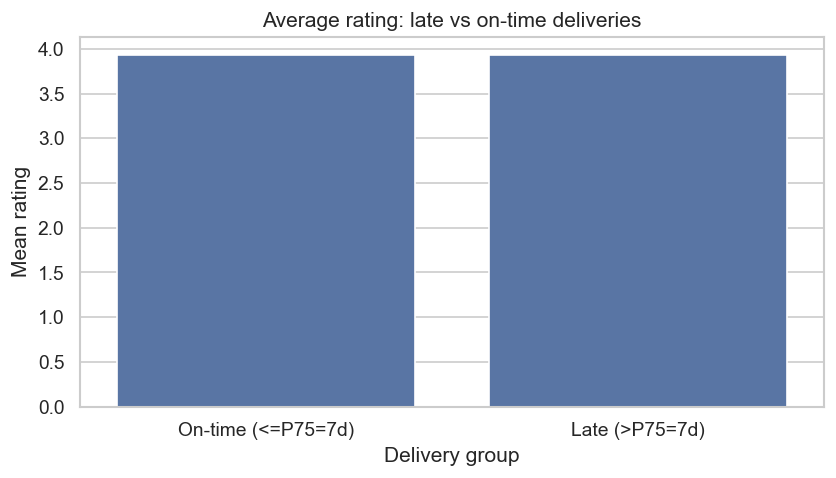

,group,n_orders,mean_rating,return_rate
0,On-time (<=P75=7d),83603,3.938375,0.0
1,Late (>P75=7d),27766,3.930088,0.0


In [18]:
# =========================================
# 9) OPTIONAL — average rating by late vs on-time group
# =========================================

rating_df = base.dropna(subset=["order_to_delivery_days", "mean_rating"]).copy()
rating_df = rating_df[rating_df["order_to_delivery_days"] >= 0].copy()

if len(rating_df) == 0:
    print("No orders with both delivery lead time and review rating.")
else:
    thr = np.nanpercentile(rating_df["order_to_delivery_days"], 75)
    rating_df["is_late"] = rating_df["order_to_delivery_days"] > thr

    rating_stats = (
        rating_df.groupby("is_late")
        .agg(
            n_orders=("order_id", "nunique"),
            mean_rating=("mean_rating", "mean"),
            return_rate=("return_flag", "mean"),
        )
        .reset_index()
    )
    rating_stats["group"] = rating_stats["is_late"].map({
        False: f"On-time (<=P75={thr:.0f}d)",
        True: f"Late (>P75={thr:.0f}d)",
    })

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=rating_stats, x="group", y="mean_rating", ax=ax)
    ax.set_title("Average rating: late vs on-time deliveries")
    ax.set_xlabel("Delivery group")
    ax.set_ylabel("Mean rating")
    plt.show()

    display(rating_stats[["group", "n_orders", "mean_rating", "return_rate"]])


## 10) Final recommendation for the 1-page report

**Main finding.** The evidence does not support delivery delay as the main driver of overall product returns. Return rate is broadly similar across delivery lead-time buckets, and monthly late-share is not a stable leading indicator of future return rate.

**Business implication.** Refund loss is concentrated in product-related issues. `wrong_size` is the largest refund driver, followed by `defective` and `not_as_described`. This means the most direct refund-reduction lever is not only logistics optimization, but better product-fit guidance, quality control, and expectation management.

**Recommended actions.**

1. Prioritize `wrong_size` reduction for high-refund product groups with better size charts, fit notes, model-size references, and fit recommendation prompts.
2. Track `defective` by product category and segment through a quality-control dashboard.
3. Reduce `not_as_described` through better product images, material descriptions, and expectation-setting content.
4. Keep late delivery as a customer-experience KPI, but do not use it as the primary return-reduction lever.

**One-sentence takeaway for the report.** In this dataset, returns appear to be primarily a product-fit and expectation-management problem rather than a delivery-delay problem; therefore, the highest-impact refund-saving lever is to reduce `wrong_size`, `defective`, and `not_as_described` returns.
